Импорт необходимых библиотек

In [1]:
import os
from dotenv import load_dotenv
import requests as r
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import margins
from seaborn import objects as so

Загружаем данные по API

In [2]:
load_dotenv()

DATE_BEGIN = os.getenv('DATE_BEGIN')
DATE_END = os.getenv('DATE_END')
API_URL = os.getenv('API_URL')

current_dir = os.getcwd()
charts_dir = os.path.join(current_dir, 'charts')

if not os.path.exists(charts_dir):
    os.mkdir(charts_dir)

response_visits = r.get(f'{API_URL}/visits?begin={DATE_BEGIN}&end={DATE_END}')

visits_json = response_visits.json()
df_visits = pd.DataFrame(visits_json)
    
response_registrations = r.get(f'{API_URL}/registrations?begin={DATE_BEGIN}&end={DATE_END}')

registrations_json = response_registrations.json()
df_registrations = pd.DataFrame(registrations_json)

Проверяем данные визитов и регистраций

In [3]:
df_visits.describe()

,visit_id,platform,user_agent,datetime
count,263459,263459,263459,263459
unique,146085,4,32,261204
top,5bc5880c-0a50-4612-93d5-5bbf9fe39e7d,web,Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:109...,2023-07-21T14:18:09
freq,4,236301,13623,3


In [4]:
df_visits.info()

<class 'pandas.DataFrame'>
RangeIndex: 263459 entries, 0 to 263458
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   visit_id    263459 non-null  str  
 1   platform    263459 non-null  str  
 2   user_agent  263459 non-null  str  
 3   datetime    263459 non-null  str  
dtypes: str(4)
memory usage: 8.0 MB


In [5]:
df_visits.head()

,visit_id,platform,user_agent,datetime
0,59c69c6f-81b3-4e63-b1b3-00a950cf9feb,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_11_2...,2023-07-17T22:11:52
1,a82c5ae1-3d3b-485e-a483-df963c5e0e7a,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_11_2...,2023-07-21T16:44:14
2,a82c5ae1-3d3b-485e-a483-df963c5e0e7a,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_11_2...,2023-07-18T04:13:34
3,87525d18-3dce-4d81-8fa8-47d900c70a90,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,2023-07-21T23:35:16
4,87525d18-3dce-4d81-8fa8-47d900c70a90,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,2023-07-20T20:23:04


In [6]:
df_registrations.describe()

,datetime,user_id,email,platform,registration_type
count,21836,21836,21836,21836,21836
unique,21821,21836,20868,3,4
top,2023-03-01T09:53:07,2e0f6bb8-b029-4f45-a786-2b53990d37f1,ujones@example.com,android,email
freq,2,1,6,10582,8996


In [7]:
df_registrations.info()

<class 'pandas.DataFrame'>
RangeIndex: 21836 entries, 0 to 21835
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   datetime           21836 non-null  str  
 1   user_id            21836 non-null  str  
 2   email              21836 non-null  str  
 3   platform           21836 non-null  str  
 4   registration_type  21836 non-null  str  
dtypes: str(5)
memory usage: 853.1 KB


In [8]:
df_registrations.head()

,datetime,user_id,email,platform,registration_type
0,2023-03-01T07:40:13,2e0f6bb8-b029-4f45-a786-2b53990d37f1,ebyrd@example.org,web,google
1,2023-03-01T13:14:00,f007f97c-9d8b-48b5-af08-119bb8f6d9b6,knightgerald@example.org,web,email
2,2023-03-01T03:05:50,24ff46ae-32b3-4a74-8f27-7cf0b8f32f15,cherylthompson@example.com,web,apple
3,2023-03-01T00:04:47,3e9914e1-5d73-4c23-b25d-b59a3aeb2b60,halldavid@example.org,web,email
4,2023-03-01T18:31:52,27f875fc-f8ce-4aeb-8722-0ecb283d0760,denise86@example.net,web,google


Работаем с визитами

In [9]:
# Приводим к формату datetime
df_visits['datetime'] = pd.to_datetime(df_visits['datetime'])

# Выбираем последний визит для каждого пользователя
filtered_visits = df_visits.sort_values(by=['visit_id','datetime'], ascending=[True, False])
filtered_visits = filtered_visits.drop_duplicates(subset='visit_id', keep='first')
filtered_visits.info()

<class 'pandas.DataFrame'>
Index: 146085 entries, 197906 to 99036
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   visit_id    146085 non-null  str           
 1   platform    146085 non-null  str           
 2   user_agent  146085 non-null  str           
 3   datetime    146085 non-null  datetime64[us]
dtypes: datetime64[us](1), str(3)
memory usage: 5.6 MB


In [10]:
# Убираем ботов
bot_mask = filtered_visits['user_agent'].str.contains('bot', case=False)
filtered_visits = filtered_visits[~bot_mask]
filtered_visits.info()

<class 'pandas.DataFrame'>
Index: 138703 entries, 197906 to 99036
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   visit_id    138703 non-null  str           
 1   platform    138703 non-null  str           
 2   user_agent  138703 non-null  str           
 3   datetime    138703 non-null  datetime64[us]
dtypes: datetime64[us](1), str(3)
memory usage: 5.3 MB


In [11]:
# Приводим формат datetime к YYYY-MM-DD в новом столбце
filtered_visits['date_group'] = pd.to_datetime(filtered_visits['datetime']).dt.date
filtered_visits['date_group'] = pd.to_datetime(filtered_visits['date_group'], format='%Y-%m-%d')
filtered_visits.info()

<class 'pandas.DataFrame'>
Index: 138703 entries, 197906 to 99036
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   visit_id    138703 non-null  str           
 1   platform    138703 non-null  str           
 2   user_agent  138703 non-null  str           
 3   datetime    138703 non-null  datetime64[us]
 4   date_group  138703 non-null  datetime64[s] 
dtypes: datetime64[s](1), datetime64[us](1), str(3)
memory usage: 6.3 MB


In [12]:
# Удаляем ненужные столбцы
filtered_visits = filtered_visits.drop(columns=['datetime', 'user_agent'])
filtered_visits.info()

<class 'pandas.DataFrame'>
Index: 138703 entries, 197906 to 99036
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype        
---  ------      --------------   -----        
 0   visit_id    138703 non-null  str          
 1   platform    138703 non-null  str          
 2   date_group  138703 non-null  datetime64[s]
dtypes: datetime64[s](1), str(2)
memory usage: 4.2 MB


Работаем с регистрациями

In [13]:
# Приводим к формату datetime и добавляем столбец с датой
df_registrations['date_group'] = pd.to_datetime(df_registrations['datetime']).dt.date
df_registrations['date_group'] = pd.to_datetime(df_registrations['date_group'], format='%Y-%m-%d')
df_registrations.info()

<class 'pandas.DataFrame'>
RangeIndex: 21836 entries, 0 to 21835
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype        
---  ------             --------------  -----        
 0   datetime           21836 non-null  str          
 1   user_id            21836 non-null  str          
 2   email              21836 non-null  str          
 3   platform           21836 non-null  str          
 4   registration_type  21836 non-null  str          
 5   date_group         21836 non-null  datetime64[s]
dtypes: datetime64[s](1), str(5)
memory usage: 1023.7 KB


In [14]:
# Удаляем ненужные столбцы
filtered_registrations = df_registrations.drop(columns=['datetime', 'email', 'registration_type'])
filtered_registrations.info()

<class 'pandas.DataFrame'>
RangeIndex: 21836 entries, 0 to 21835
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype        
---  ------      --------------  -----        
 0   user_id     21836 non-null  str          
 1   platform    21836 non-null  str          
 2   date_group  21836 non-null  datetime64[s]
dtypes: datetime64[s](1), str(2)
memory usage: 511.9 KB


Агрегация визитов и регистраций

In [15]:
# Группируем визиты по дате и платформе
visits_result = filtered_visits.groupby(['date_group', 'platform']).agg(visits = ('visit_id', 'count'))
visits_result = visits_result.reset_index()
visits_result.info()

<class 'pandas.DataFrame'>
RangeIndex: 552 entries, 0 to 551
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype        
---  ------      --------------  -----        
 0   date_group  552 non-null    datetime64[s]
 1   platform    552 non-null    str          
 2   visits      552 non-null    int64        
dtypes: datetime64[s](1), int64(1), str(1)
memory usage: 13.1 KB


In [16]:
# Группируем регистрации по дате и платформе
registrations_result = filtered_registrations.groupby(['date_group', 'platform']).agg(registrations = ('user_id', 'count'))
registrations_result = registrations_result.reset_index()
registrations_result.info()

<class 'pandas.DataFrame'>
RangeIndex: 552 entries, 0 to 551
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype        
---  ------         --------------  -----        
 0   date_group     552 non-null    datetime64[s]
 1   platform       552 non-null    str          
 2   registrations  552 non-null    int64        
dtypes: datetime64[s](1), int64(1), str(1)
memory usage: 13.1 KB


Объединение данных визитов и регистраций

In [28]:
# Объединяем визиты и регистрации
df_conversion = visits_result.merge(registrations_result, left_on=['date_group', 'platform'], right_on=['date_group', 'platform'])

# Считаем конверсию
df_conversion['conversion'] = df_conversion['registrations'] / df_conversion['visits'] * 100
df_conversion = df_conversion.sort_values(by=['date_group'])

# Экспортируем результат в формате json
df_conversion.to_json('./conversion.json')

df_conversion.info()

<class 'pandas.DataFrame'>
Index: 552 entries, 0 to 551
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype        
---  ------         --------------  -----        
 0   date_group     552 non-null    datetime64[s]
 1   platform       552 non-null    str          
 2   visits         552 non-null    int64        
 3   registrations  552 non-null    int64        
 4   conversion     552 non-null    float64      
dtypes: datetime64[s](1), float64(1), int64(2), str(1)
memory usage: 42.0 KB


/var/folders/2x/jdxq54y50nbc_1w9txxsr4zw0000gn/T/ipykernel_18985/2531131152.py:9: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  df_conversion.to_json('./conversion.json')


Расчеты рекламы

In [29]:
# Создаем датафрейм на основе df_conversion
df_vis_reg = df_conversion.drop(columns=['conversion'])
df_vis_reg.groupby('date_group').agg(visits=('visits', 'sum'), registrations = ('registrations', 'sum'))
df_vis_reg = df_vis_reg.reset_index()
df_vis_reg.info()

<class 'pandas.DataFrame'>
RangeIndex: 552 entries, 0 to 551
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype        
---  ------         --------------  -----        
 0   index          552 non-null    int64        
 1   date_group     552 non-null    datetime64[s]
 2   platform       552 non-null    str          
 3   visits         552 non-null    int64        
 4   registrations  552 non-null    int64        
dtypes: datetime64[s](1), int64(3), str(1)
memory usage: 21.7 KB


In [30]:
# Загружаем данные о рекламных кампаниях
df_ads = pd.read_csv('./ads.csv')
df_ads.info()

<class 'pandas.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   date          159 non-null    str  
 1   utm_source    159 non-null    str  
 2   utm_medium    159 non-null    str  
 3   utm_campaign  159 non-null    str  
 4   cost          159 non-null    int64
dtypes: int64(1), str(4)
memory usage: 6.3 KB


In [31]:
# Приводим дату к формату datetime YYYY-MM-DD в новом слолбце
df_ads['date_group'] = pd.to_datetime(df_ads['date']).dt.date
df_ads['date_group'] = pd.to_datetime(df_ads['date_group'], format='%Y-%m-%d')

# Удаляем ненужные столбцы
df_ads = df_ads.drop(columns=['date', 'utm_source', 'utm_medium'])

df_ads.info()

<class 'pandas.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype        
---  ------        --------------  -----        
 0   utm_campaign  159 non-null    str          
 1   cost          159 non-null    int64        
 2   date_group    159 non-null    datetime64[s]
dtypes: datetime64[s](1), int64(1), str(1)
memory usage: 3.9 KB


Объединение визитов, регистраций и рекламы

In [33]:
# Объединяем датафреймы df_vis_reg и df_ads
df_result = df_vis_reg.merge(df_ads, left_on='date_group', right_on='date_group', how='left')
# Проставляем стоимость 0 в дни без рекламы
df_result['cost'] =df_result['cost'].fillna(0)
df_result = df_result.sort_values(by=['date_group'])

# Экспортируем в json
df_result.to_json('./ads.json')

df_result.info()

<class 'pandas.DataFrame'>
Index: 552 entries, 0 to 551
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype        
---  ------         --------------  -----        
 0   index          552 non-null    int64        
 1   date_group     552 non-null    datetime64[s]
 2   platform       552 non-null    str          
 3   visits         552 non-null    int64        
 4   registrations  552 non-null    int64        
 5   utm_campaign   426 non-null    str          
 6   cost           552 non-null    float64      
dtypes: datetime64[s](1), float64(1), int64(3), str(2)
memory usage: 50.7 KB


/var/folders/2x/jdxq54y50nbc_1w9txxsr4zw0000gn/T/ipykernel_18985/617032835.py:8: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  df_result.to_json('./ads.json')


Создаем датафрейм с датами рекламных кампаний

In [157]:
campaign_dates = df_ads.groupby(['utm_campaign']).agg(start = ('date_group', 'min'), end = ('date_group', 'max'))
campaign_dates = campaign_dates[campaign_dates['start'] < DATE_END]

campaign_dates.head()

,start,end
utm_campaign,,
advanced_algorithms_series,2023-03-01,2023-03-15
intro_to_python_course,2023-08-06,2023-09-17
ui_ux_design_drive,2023-05-19,2023-06-09
virtual_reality_workshop,2023-03-25,2023-05-06
women_in_tech_symposium,2023-06-21,2023-07-26


In [38]:
# Считаем суммарные стоимости рекламных кампаний
df_ads_cost = df_result.groupby(['utm_campaign']).agg(start = ('date_group', 'min'), end = ('date_group', 'max'), total_cost = ('cost', 'sum'),
    total_visits = ('visits', 'sum'), total_registrations = ('registrations', 'sum')).reset_index()
df_ads_cost['conversion']= df_ads_cost['total_registrations'] / df_ads_cost['total_visits'] * 100

df_ads_cost.head()

,utm_campaign,start,end,total_cost,total_visits,total_registrations,conversion
0,advanced_algorithms_series,2023-03-01,2023-03-15,8472.0,14706,2196,14.932681
1,intro_to_python_course,2023-08-06,2023-08-31,14070.0,22917,3246,14.164158
2,ui_ux_design_drive,2023-05-19,2023-06-09,12627.0,14398,2308,16.030004
3,virtual_reality_workshop,2023-03-25,2023-05-06,27093.0,32698,5898,18.037800
4,women_in_tech_symposium,2023-06-21,2023-07-26,20340.0,31028,4184,13.484595


Визуализация

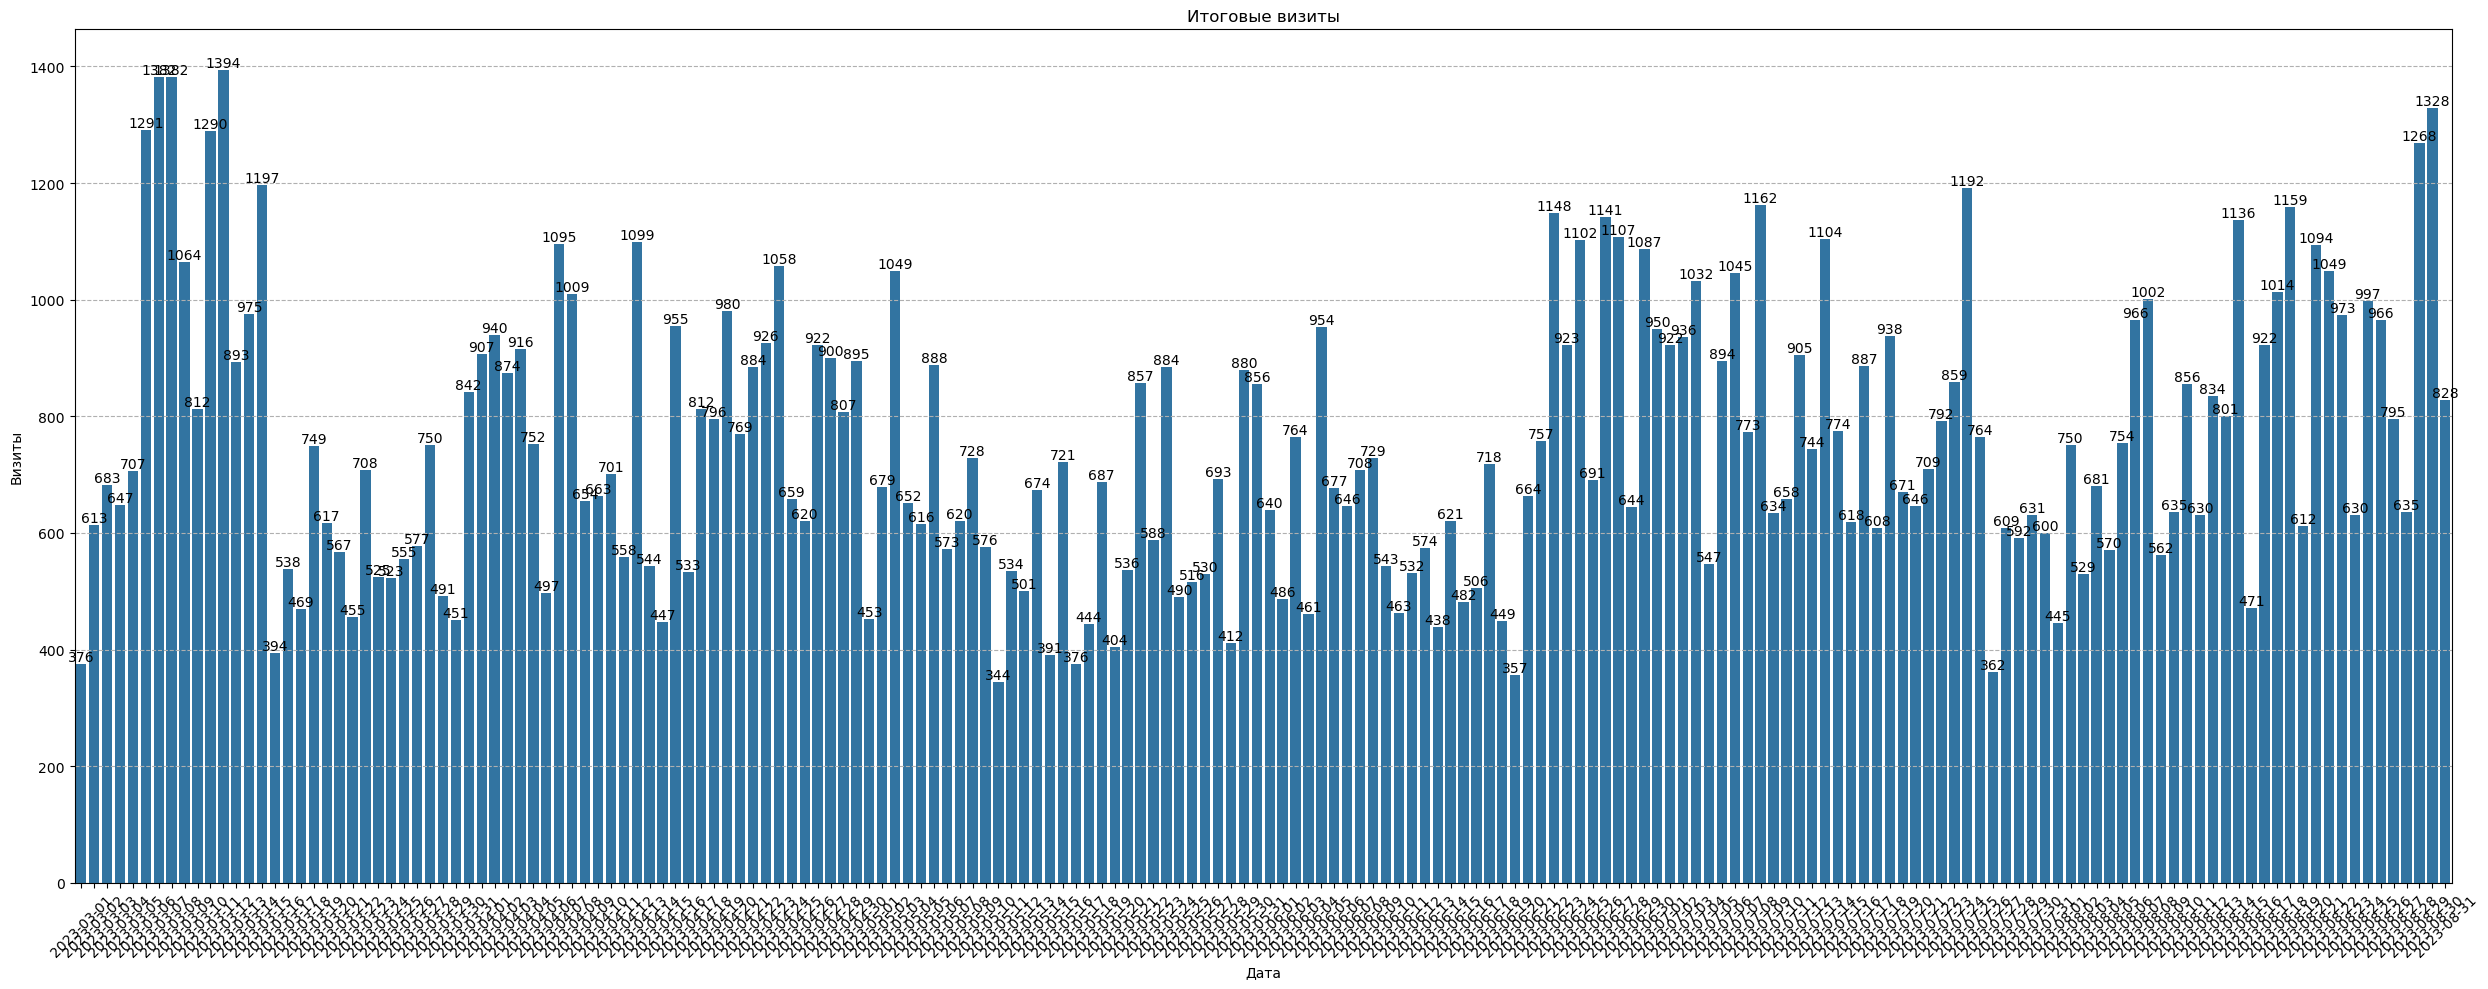

In [76]:
# Столбчатая диаграмма итоговых визитов по дням
plt.style.use('default')
fig, ax = plt.subplots(figsize=(25, 10))

sns.barplot(
    data=df_vis_reg,
    x='date_group',
    y='visits',
    estimator='sum',
    errorbar=None,
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fontsize=10)

ax.set_title('Итоговые визиты')
plt.xlabel('Дата')
plt.ylabel('Визиты')
ax.tick_params(axis='x', rotation=45)

ax.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.savefig('./charts/total_visits.png')

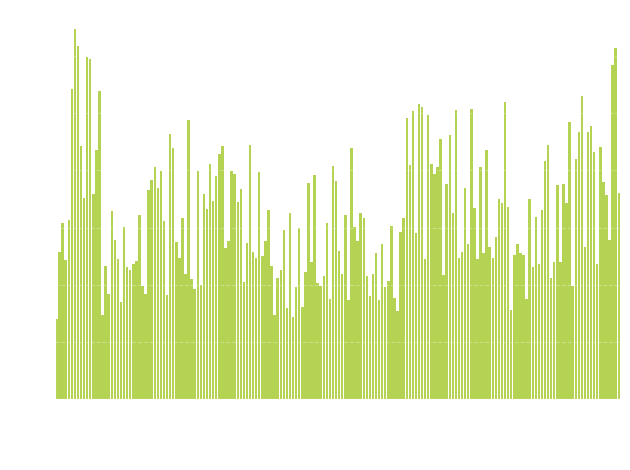

In [52]:
# Столбчатая диаграмма итоговых визитов по дням dark-theme-vector
fig, ax = plt.subplots()

ax.bar(df_vis_reg['date_group'], df_vis_reg['visits'], color='#B4D352')

ax.tick_params(axis='x', colors='white', rotation=45)
ax.tick_params(axis='y', colors='white')

ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(axis='y', color='white', linestyle='--', alpha=0.3)

plt.margins(x=0)
plt.tight_layout()

plt.savefig('./presentable_charts/total_visits_dark.svg', transparent=True)

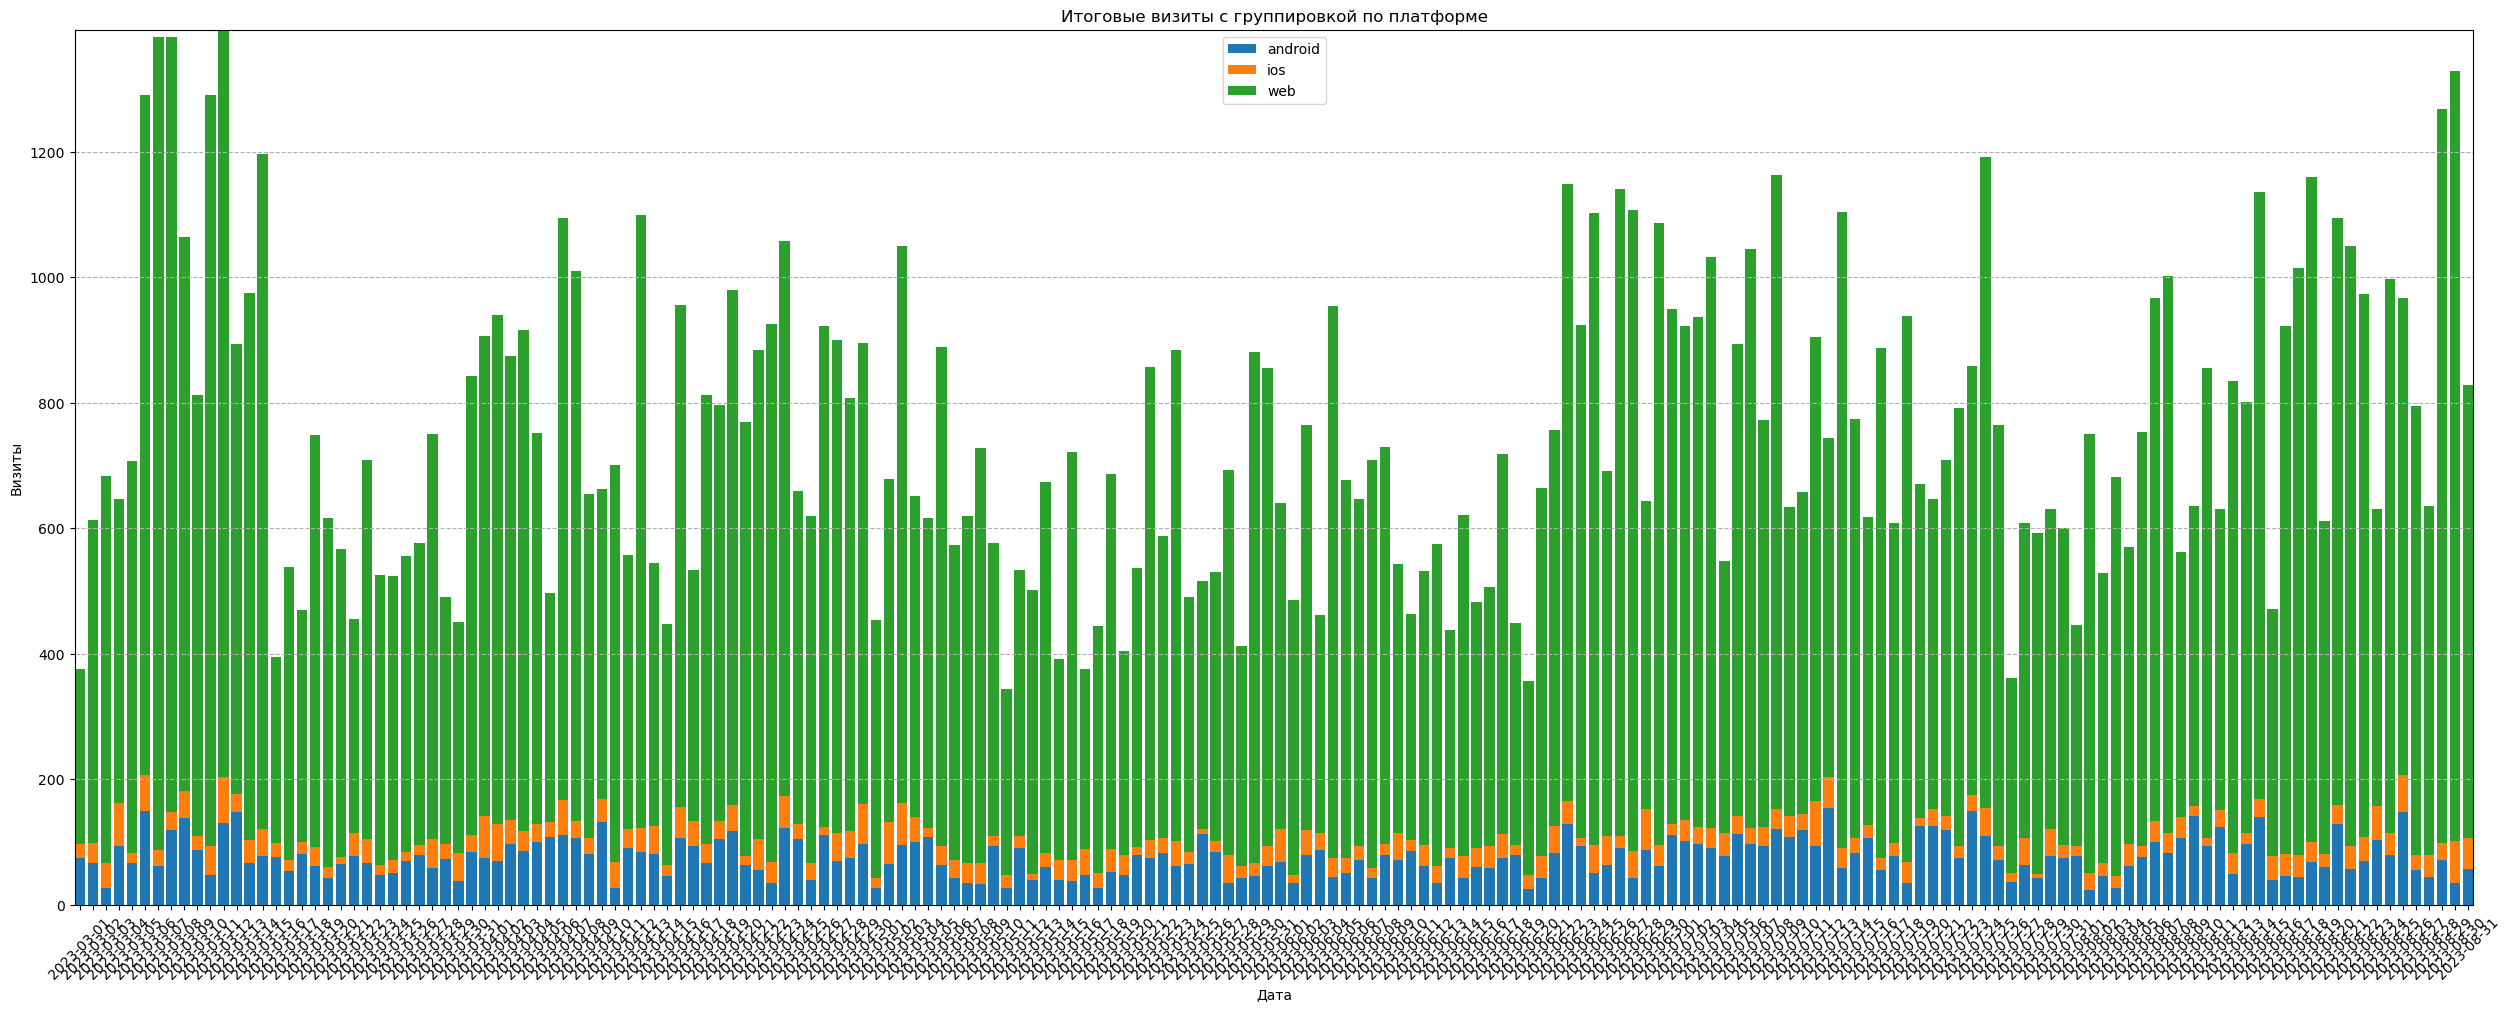

In [78]:
# Столбчатая диаграмма итоговых визитов по дням с группировкой по платформе
plt.figure(num=None, layout='constrained', figsize=(25, 10))

plot_df = (
    df_vis_reg.groupby(['date_group', 'platform'])['visits']
    .sum()
    .unstack(fill_value=0)
    .sort_index()
)

bottom = pd.Series(0, index=plot_df.index)

for platform in plot_df.columns:
    bars = plt.bar(
        plot_df.index,
        plot_df[platform],
        bottom=bottom,
        label=platform
    )

    bottom += plot_df[platform]

plt.title('Итоговые визиты с группировкой по платформе')
plt.xlabel('Дата')
plt.ylabel('Визиты')
plt.xticks(plot_df.index, rotation=45)
plt.grid(axis='y', linestyle='--')
plt.legend()
plt.margins(0)

plt.savefig('./charts/total_visits_by_platform.png')

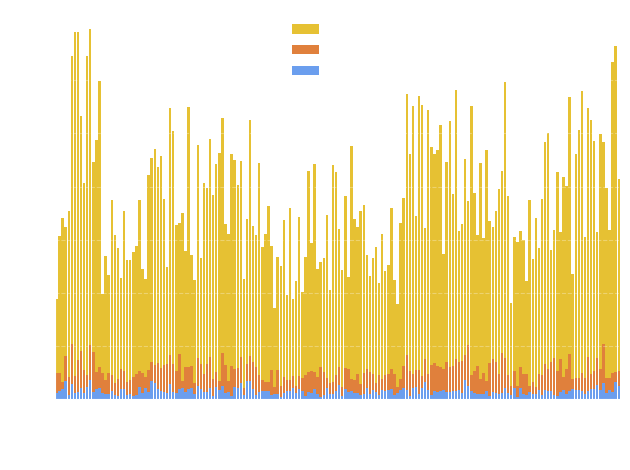

In [69]:
# Столбчатая диаграмма итоговых визитов по дням с группировкой по платформе
# dark-theme vector
plt.style.use('default')

plot_df = (
    df_vis_reg.groupby(['date_group', 'platform'])['visits']
    .sum()
    .unstack()
    .sort_index()
)

plot_df = plot_df[['ios', 'android', 'web']]

colors = {
    'android': '#E0803C',  # оранжевый
    'ios':     '#6B9EEE',  # голубой
    'web':     '#E6C133'   # желтый
}

fig, ax = plt.subplots()

bottom = pd.Series(0, index=plot_df.index)

for platform in plot_df.columns:
    ax.bar(
        plot_df.index,
        plot_df[platform],
        bottom=bottom,
        label=platform,
        color=colors[platform]
    )
    bottom += plot_df[platform]

ax.tick_params(axis='x', colors='white', rotation=45)
ax.tick_params(axis='y', colors='white')

ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(axis='y', color='white', linestyle='--', alpha=0.3)

legend = ax.legend(reverse=True)
for text in legend.get_texts():
    text.set_color('white')
legend.get_frame().set_alpha(0)

plt.margins(x=0)
plt.tight_layout()

plt.savefig('./presentable_charts/total_visits_by_platform_dark.svg', transparent=True)

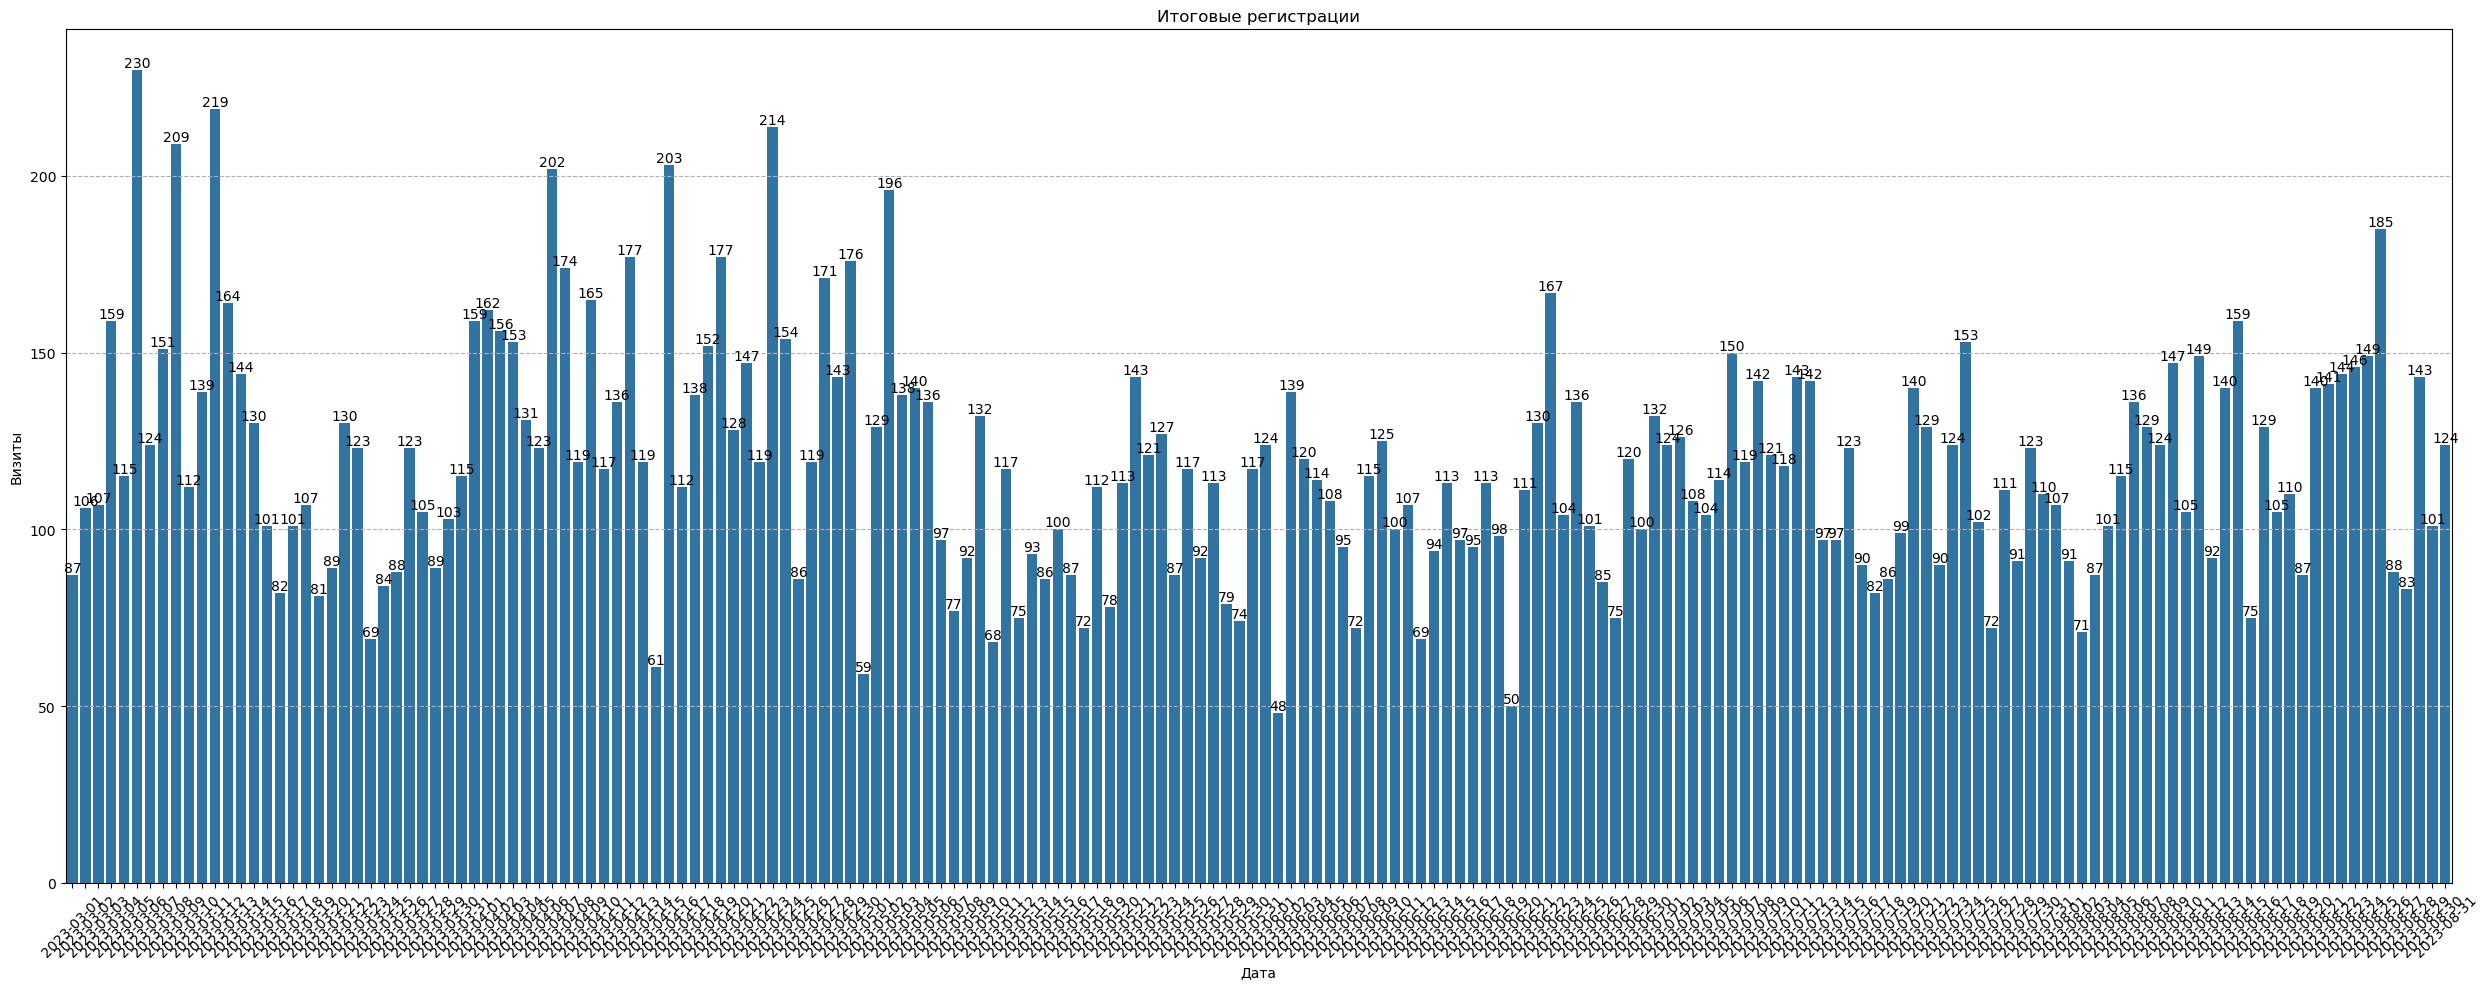

In [79]:
# Столбчатая диаграмма итоговых регистраций по дням
plt.style.use('default')
fig, ax = plt.subplots(figsize=(25, 10))

sns.barplot(
    data=df_vis_reg,
    x='date_group',
    y='registrations',
    estimator='sum',
    errorbar=None,
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fontsize=10)

ax.set_title('Итоговые регистрации')
plt.xlabel('Дата')
plt.ylabel('Визиты')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.savefig('./charts/total_registrations.png')

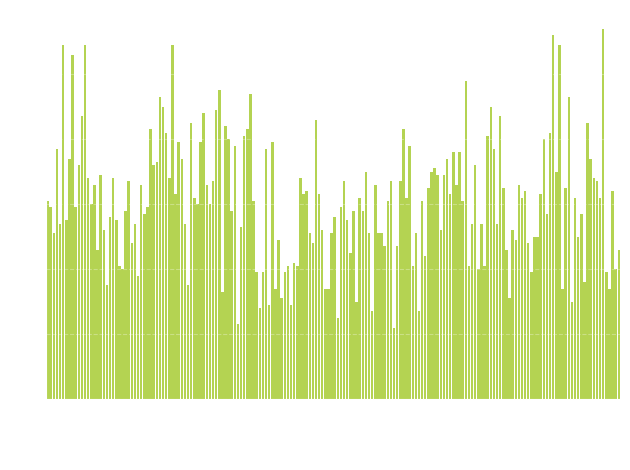

In [72]:
# Столбчатая диаграмма итоговых регистраций по дням dark-theme-vector
fig, ax = plt.subplots()

ax.bar(df_vis_reg['date_group'], df_vis_reg['registrations'], color='#B4D352')

ax.tick_params(axis='x', colors='white', rotation=45)
ax.tick_params(axis='y', colors='white')

ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(axis='y', color='white', linestyle='--', alpha=0.3)

plt.margins(x=0)
plt.tight_layout()

plt.savefig('./presentable_charts/total_registrations_dark.svg', transparent=True)

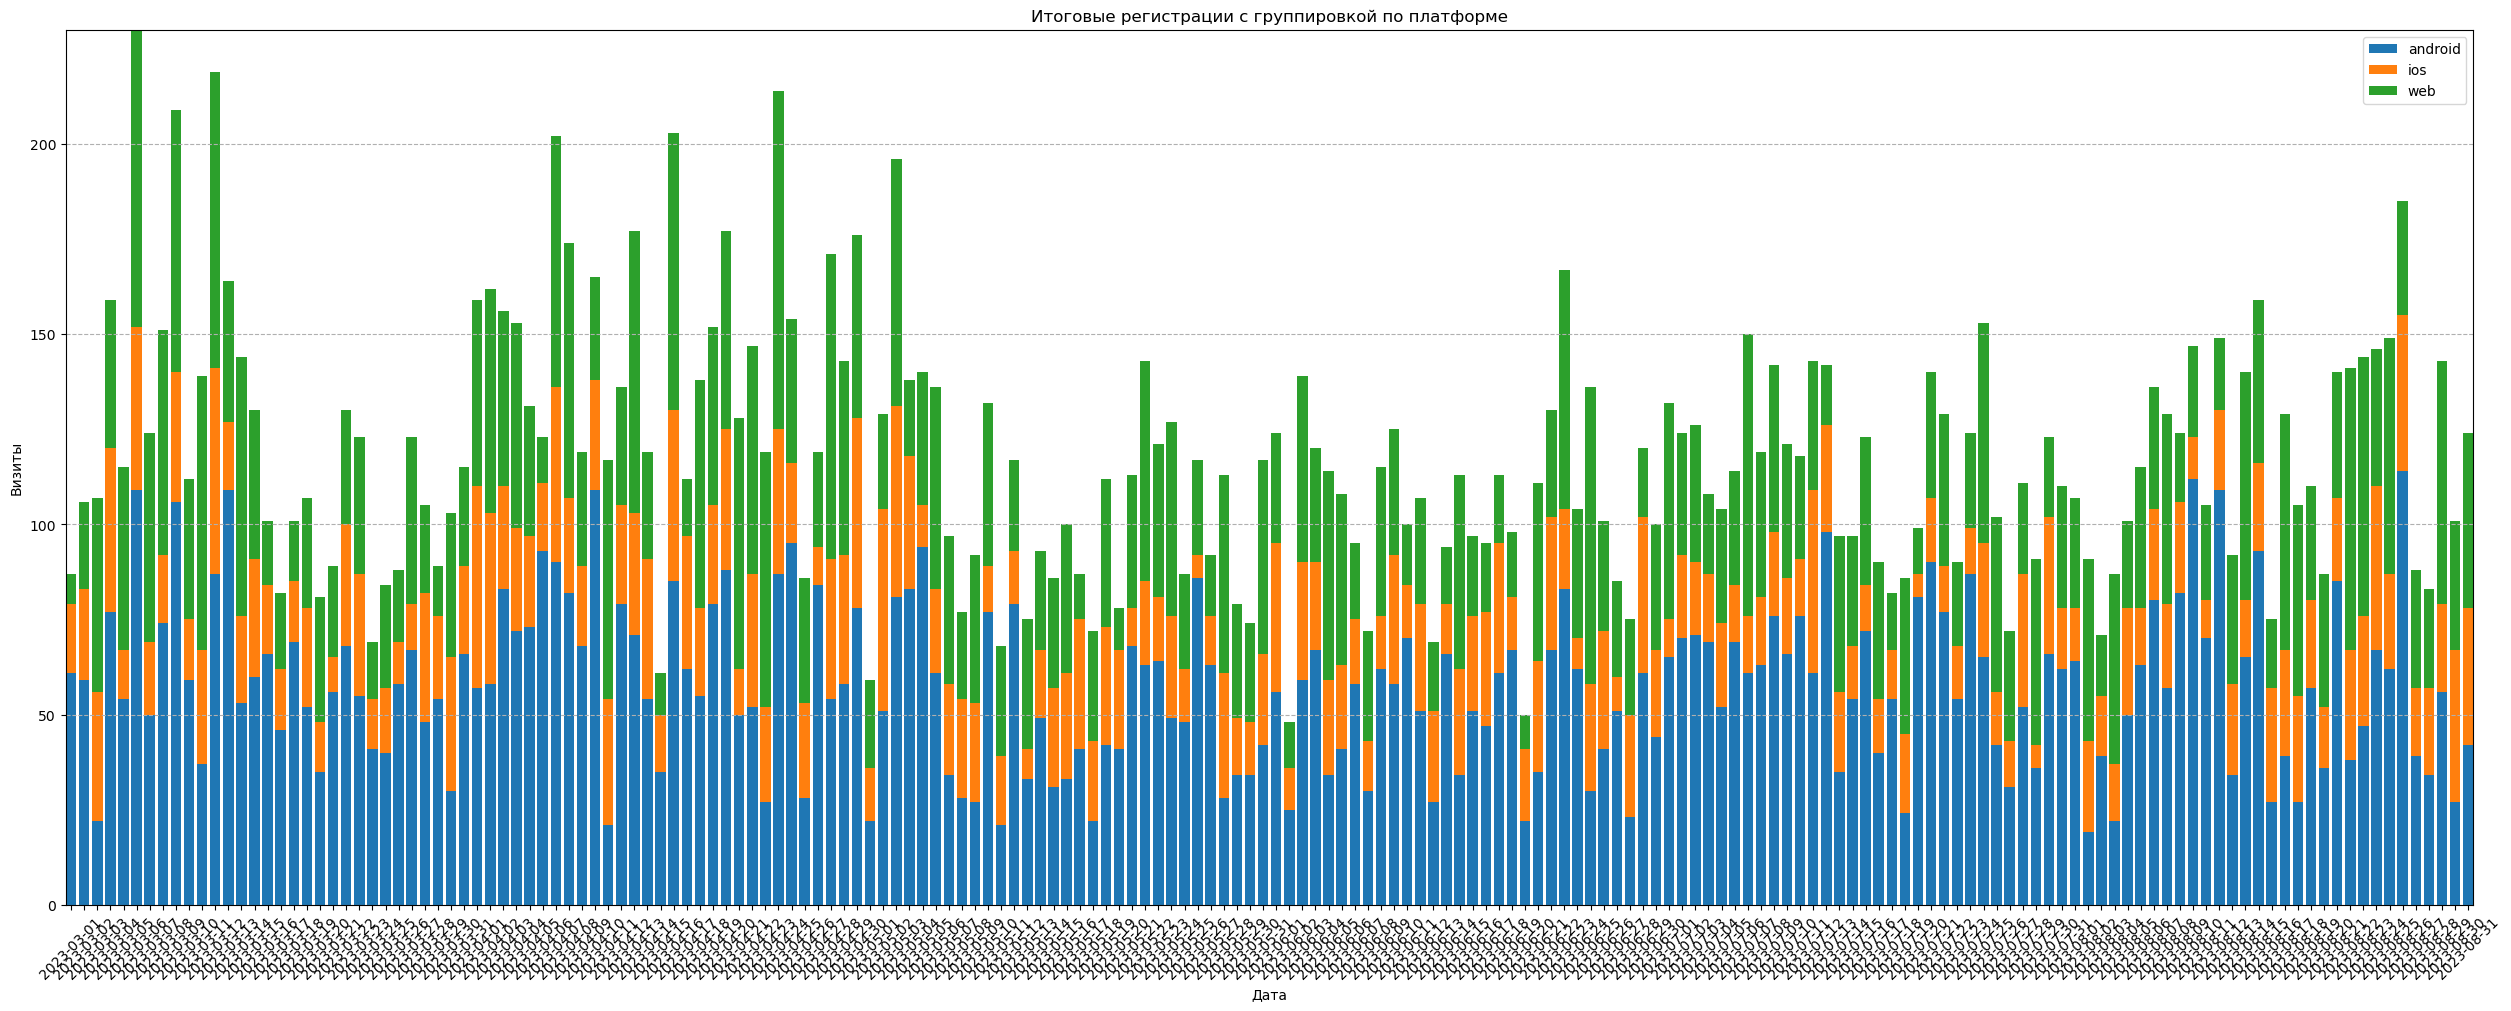

In [80]:
# Столбчатая диаграмма итоговых регистраций по дням с группировкой по платформе
plt.figure(num=None, layout='constrained', figsize=(25, 10))

plot_df = (
    df_vis_reg.groupby(['date_group', 'platform'])['registrations']
    .sum()
    .unstack(fill_value=0)
    .sort_index()
)

bottom = pd.Series(0, index=plot_df.index)

for platform in plot_df.columns:
    bars = plt.bar(
        plot_df.index,
        plot_df[platform],
        bottom=bottom,
        label=platform
    )

    bottom += plot_df[platform]

plt.title('Итоговые регистрации с группировкой по платформе')
plt.xlabel('Дата')
plt.ylabel('Визиты')
plt.xticks(plot_df.index, rotation=45)
plt.grid(axis='y', linestyle='--')
plt.legend()
plt.margins(0)

plt.savefig('./charts/total_registrations_by_platform.png')

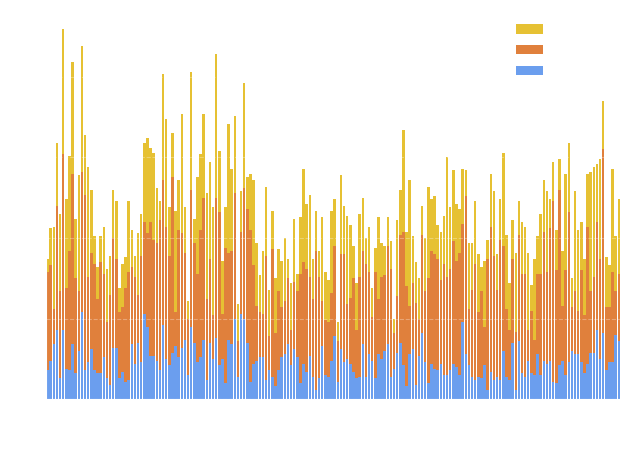

In [74]:
# Столбчатая диаграмма итоговых регистраций по дням с группировкой по платформе
# dark-theme vector
plt.style.use('default')

plot_df = (
    df_vis_reg.groupby(['date_group', 'platform'])['registrations']
    .sum()
    .unstack()
    .sort_index()
)

plot_df = plot_df[['ios', 'android', 'web']]

colors = {
    'android': '#E0803C',  # оранжевый
    'ios':     '#6B9EEE',  # голубой
    'web':     '#E6C133'   # желтый
}

fig, ax = plt.subplots()

bottom = pd.Series(0, index=plot_df.index)

for platform in plot_df.columns:
    ax.bar(
        plot_df.index,
        plot_df[platform],
        bottom=bottom,
        label=platform,
        color=colors[platform]
    )
    bottom += plot_df[platform]

ax.tick_params(axis='x', colors='white', rotation=45)
ax.tick_params(axis='y', colors='white')

ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(axis='y', color='white', linestyle='--', alpha=0.3)

legend = ax.legend(reverse=True)
for text in legend.get_texts():
    text.set_color('white')
legend.get_frame().set_alpha(0)

plt.margins(x=0)
plt.tight_layout()

plt.savefig('./presentable_charts/total_registrations_by_platform_dark.svg', transparent=True)

In [82]:
# Расчет общей конверсии
overall_conversion = df_conversion.drop(columns=['platform', 'conversion'])
overall_conversion = overall_conversion.groupby('date_group').agg(visits = ('visits', 'sum'), registrations = ('registrations', 'sum'))
overall_conversion['conversion'] = overall_conversion['registrations'] / overall_conversion['visits'] * 100
overall_conversion = overall_conversion.drop(columns=['visits', 'registrations'])
overall_conversion.head()

,conversion
date_group,
2023-03-01,23.138298
2023-03-02,17.292007
2023-03-03,15.666179
2023-03-04,24.574961
2023-03-05,16.265912


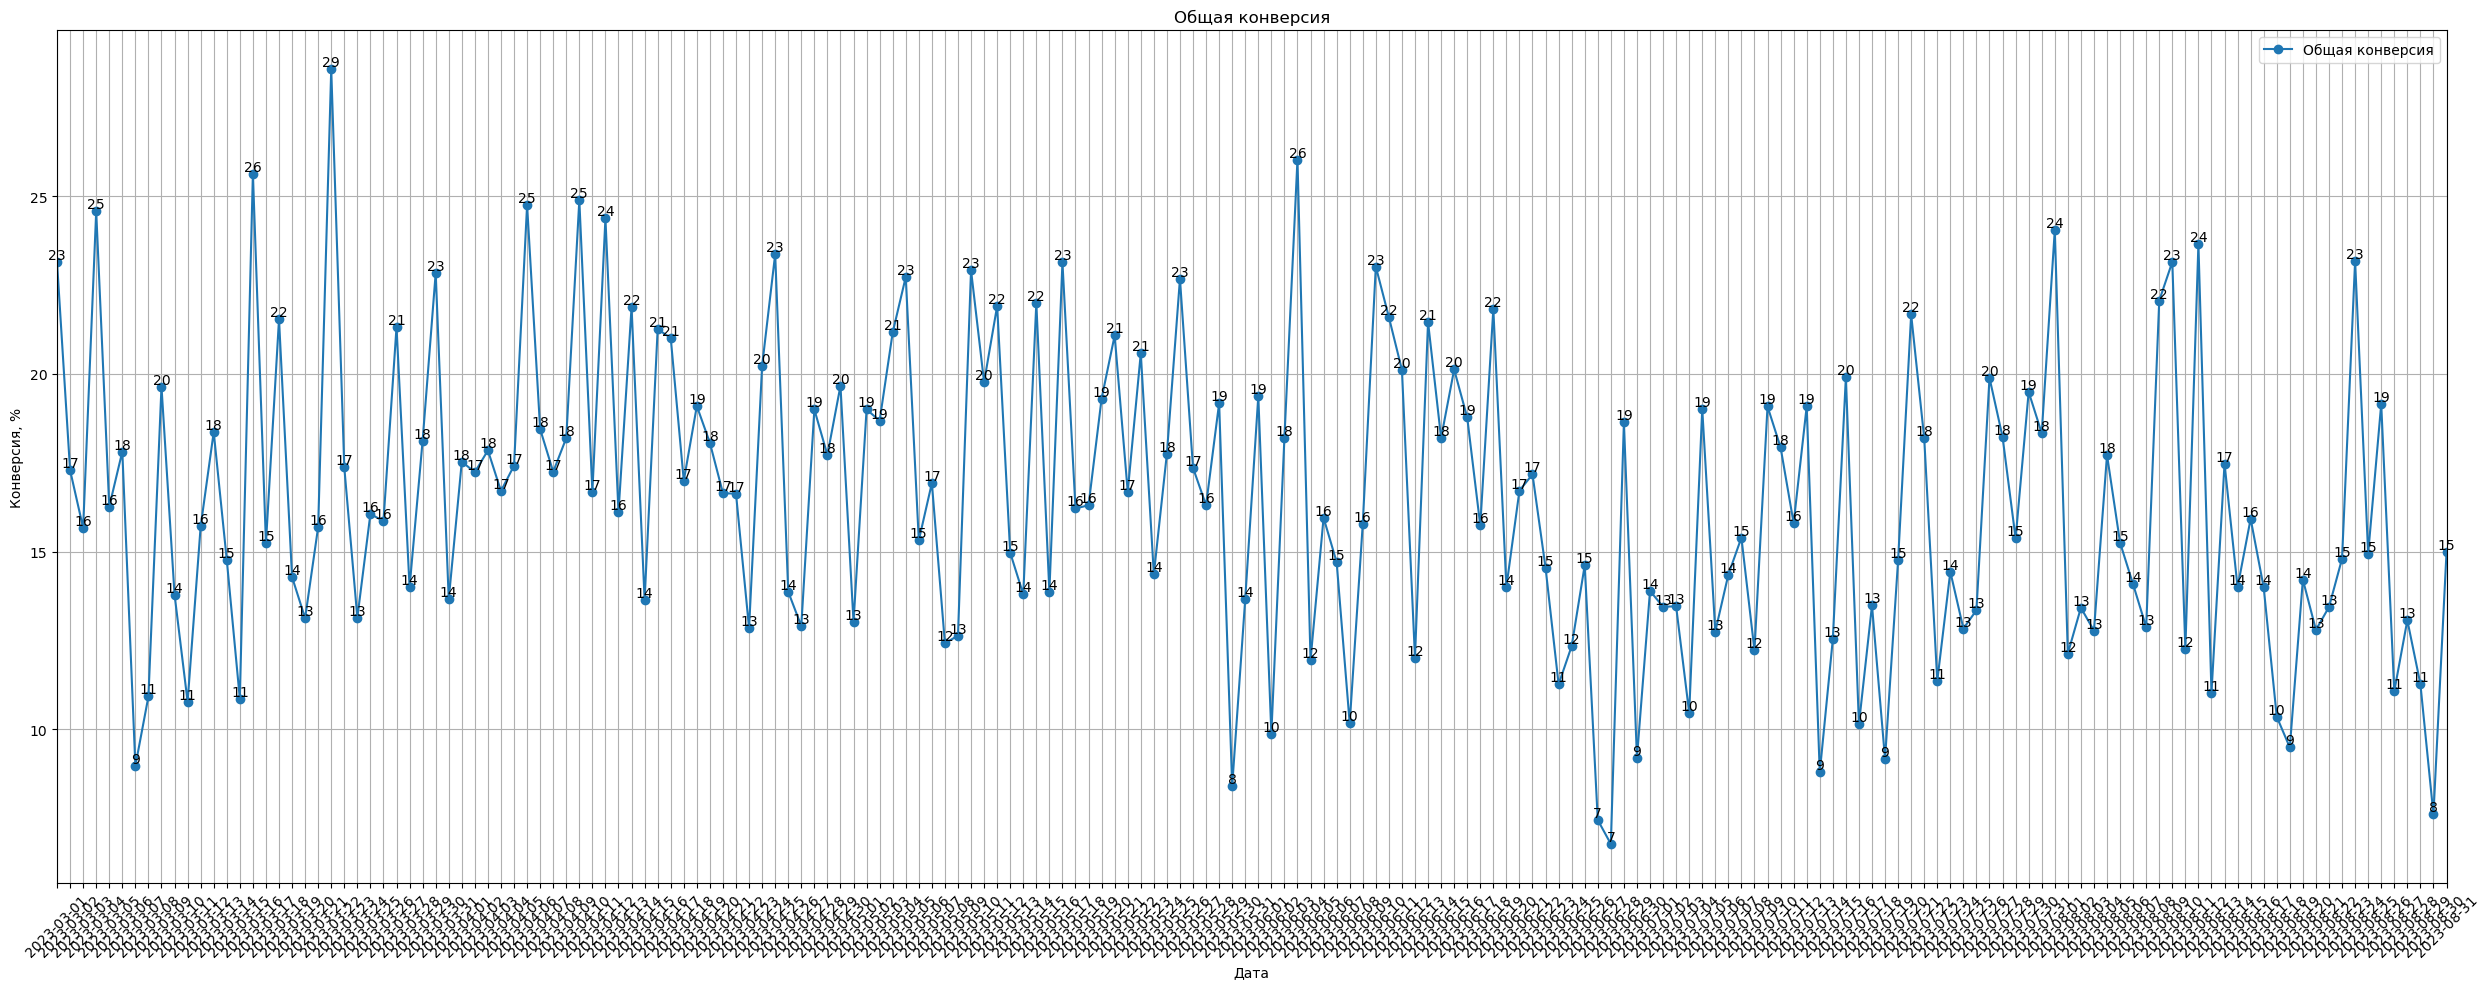

In [92]:
# Построение линейного графика общей конверсии
plt.style.use('default')
plt.figure(figsize=(25,10))

plt.plot(
    overall_conversion.index,
    overall_conversion.values,
    marker='o',
    label='Общая конверсия'
)

plt.title('Общая конверсия')
plt.xlabel('Дата')
plt.ylabel('Конверсия, %')

plt.xticks(overall_conversion.index, rotation=45)
plt.grid(True)
plt.legend()

for x, y in zip(overall_conversion.index, overall_conversion.values):
    plt.text(x, y[0], f'{y[0]:.0f}', ha='center', va='bottom')

plt.margins(x=0)
plt.tight_layout()
plt.savefig('./charts/overall_conversion.png')

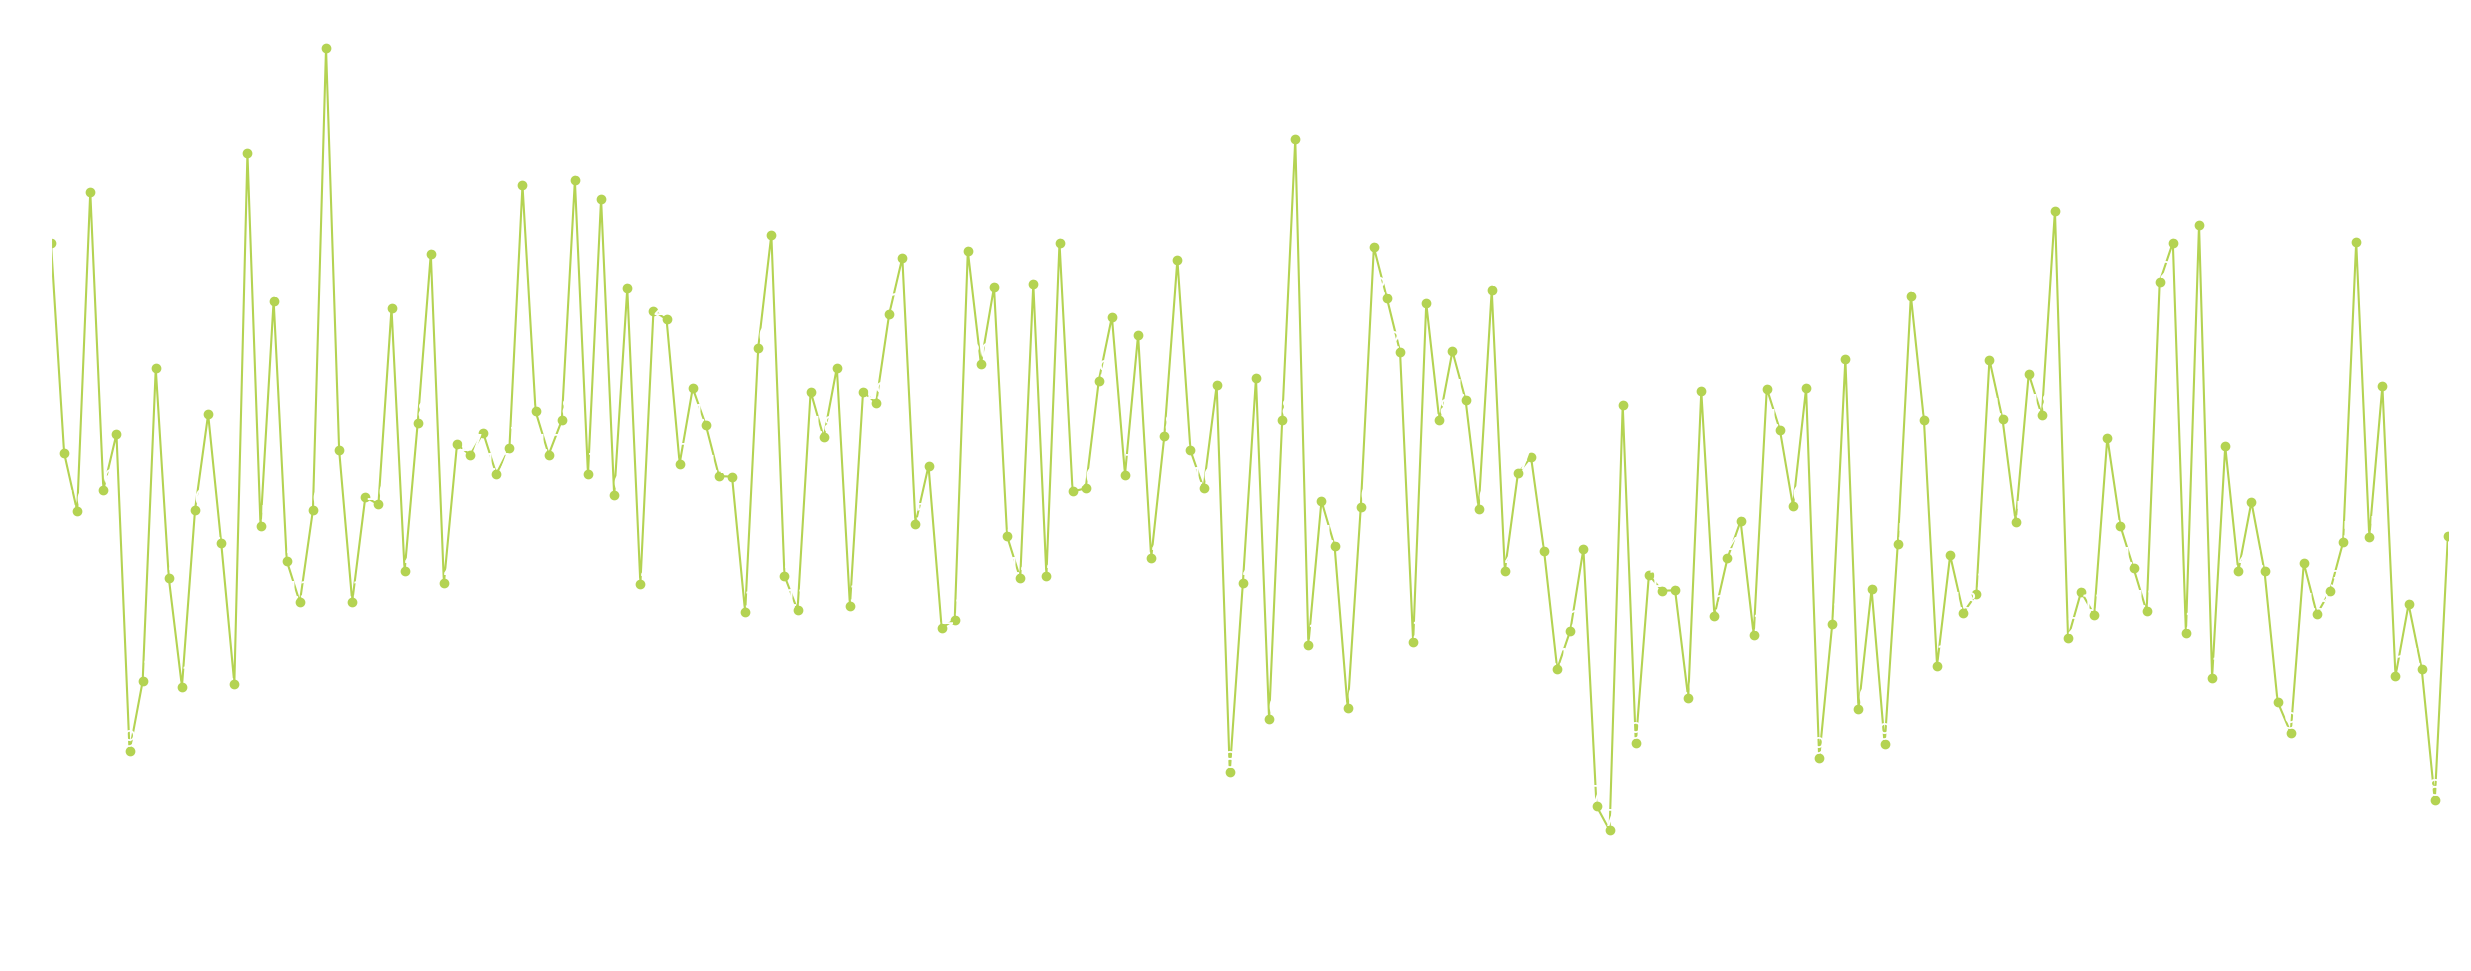

In [184]:
plt.style.use('default')

plt.rcParams.update({
    'font.size': 16
})

fig, ax = plt.subplots(figsize=(25, 10))

ax.plot(
    overall_conversion.index,
    overall_conversion.values,
    marker='o',
    color='#B4D352'
)

ax.tick_params(axis='x', colors='white', rotation=45)
ax.tick_params(axis='y', colors='white')

for x, y in zip(overall_conversion.index, overall_conversion.values):
    val = y[0]
    ax.text(x, val, f'{val:.0f}', ha='center', va='bottom', color='white')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')

ax.grid(axis='y', color='white', alpha=0.3, linestyle='--')

plt.margins(x=0)
plt.tight_layout()

plt.savefig(
    './presentable_charts/overall_conversion_dark.svg',
    transparent=True
)

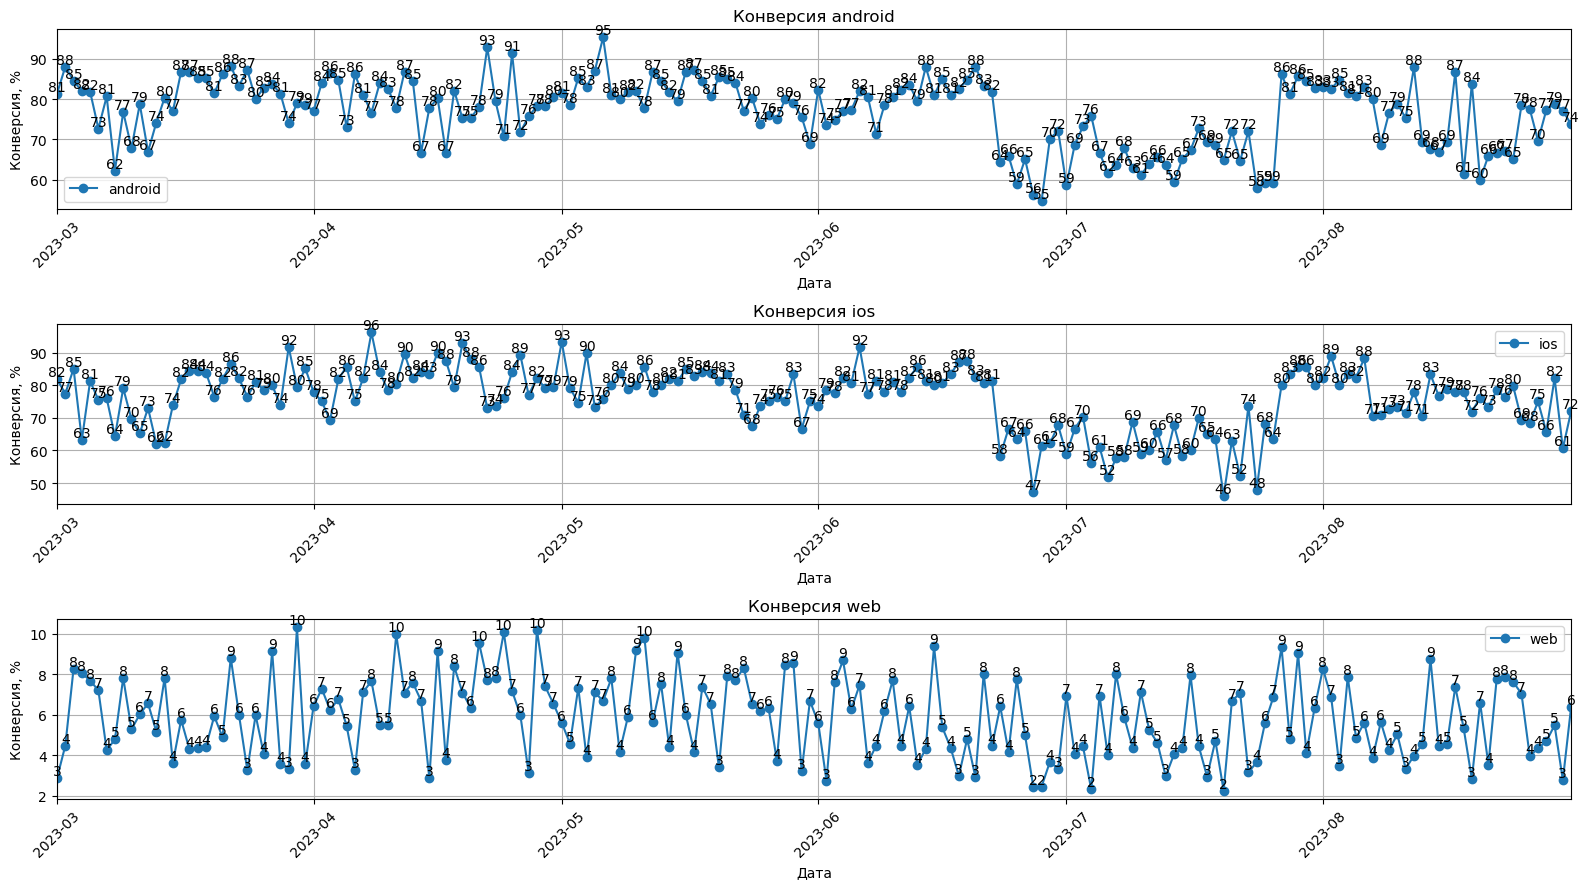

In [117]:
# График конверсии с группировкой по платформе
plt.style.use('default')
fig, axes = plt.subplots(3, 1, figsize=(16, 9))  # 1 строка, 3 графика
platforms = df_conversion['platform'].unique()
for ax, p in zip(axes, platforms):
    # подготовка данных
    platform_conversion = (
        df_conversion[df_conversion['platform'] == p]
        .drop(columns=['platform', 'visits', 'registrations'])
        .groupby('date_group')
        .sum()
    )

    # график
    ax.plot(
        platform_conversion.index,
        platform_conversion.values,
        marker='o',
        label=p
    )

    ax.set_title(f'Конверсия {p}')
    ax.set_xlabel('Дата')
    ax.set_ylabel('Конверсия, %')

    ax.tick_params(axis='x', rotation=45)
    ax.grid(True)
    ax.legend()
    ax.margins(x=0)

    # подписи
    for x, y in zip(platform_conversion.index, platform_conversion.values):
        val = y[0]
        ax.text(x, val, f'{val:.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('./charts/conversion_by_platform.png')

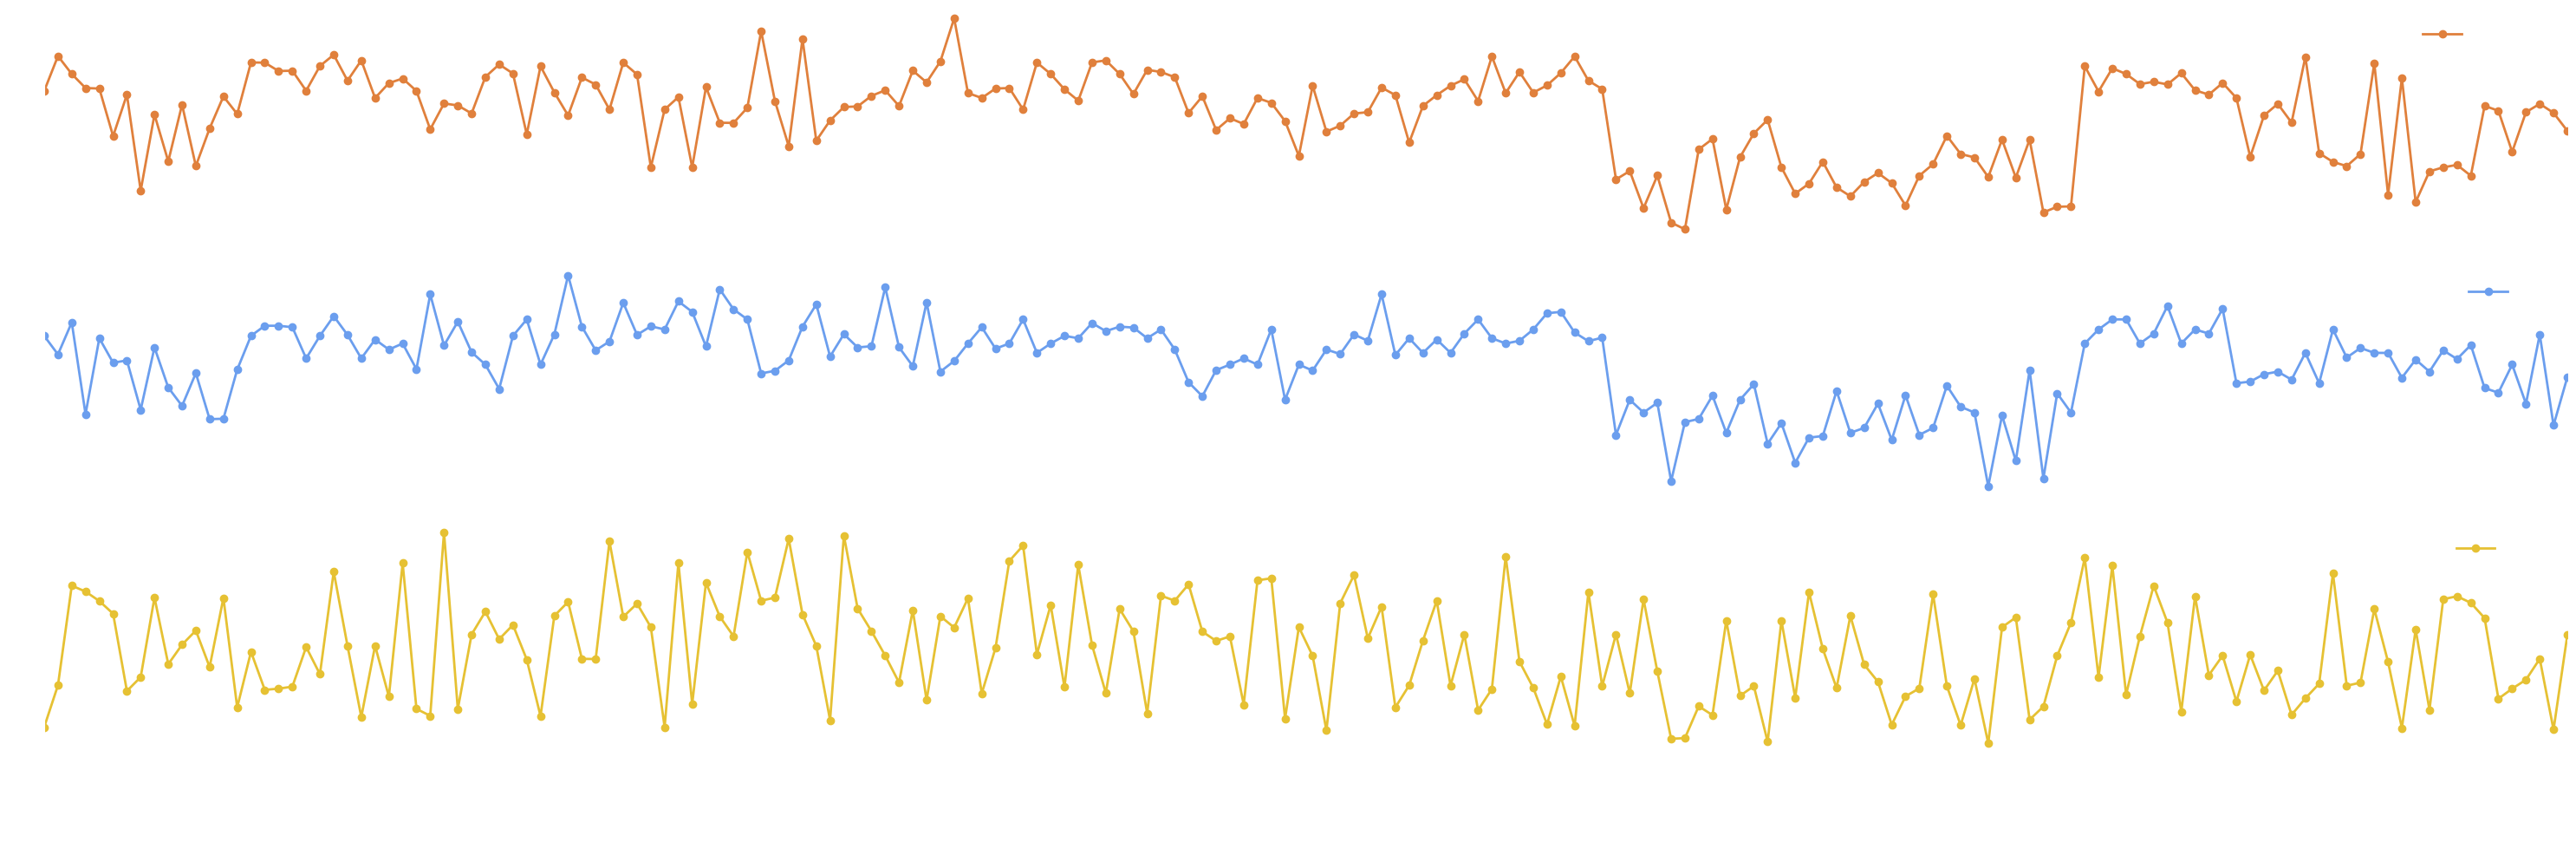

In [185]:
colors = {
    'android': '#E0803C',  # оранжевый
    'ios':     '#6B9EEE',  # голубой
    'web':     '#E6C133'   # желтый
}

plt.style.use('default')
plt.rcParams.update({'font.size': 16})

fig, axes = plt.subplots(3, 1, figsize=(30, 10), sharex=True)
platforms = df_conversion['platform'].unique()
for ax, p in zip(axes, platforms):
    platform_conversion = (
        df_conversion[df_conversion['platform'] == p]
        .drop(columns=['platform', 'visits', 'registrations'])
        .groupby('date_group')
        .sum()
    )

    ax.plot(
        platform_conversion.index,
        platform_conversion.values,
        marker='o',
        color=colors[p],
        linewidth=2,
        label=p
    )

    # легенда
    legend = ax.legend()
    for text in legend.get_texts():
        text.set_color('white')
    legend.get_frame().set_alpha(0)

    # стиль осей
    ax.tick_params(axis='y', colors='white')
    ax.tick_params(axis='x', colors='white')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('white')
    ax.spines['left'].set_color('white')

    ax.grid(axis='y', color='white', linestyle='--', alpha=0.3)

# даты только на последнем графике
for ax in axes[:-1]:
    ax.tick_params(axis='x', labelbottom=False)

axes[-1].tick_params(axis='x', rotation=45, colors='white')

plt.margins(x=0)
plt.tight_layout()

plt.savefig('./presentable_charts/conversion_by_platform_dark.svg', transparent=True)

In [124]:
# Расчет затрат на рекламу
plt_ads_cost = df_result.drop(columns=['visits', 'registrations', 'utm_campaign'])
plt_ads_cost = plt_ads_cost[plt_ads_cost['cost'] > 0]
plt_ads_cost = plt_ads_cost.groupby('date_group').sum()
plt_ads_cost.head()

,index,platform,cost
date_group,,,
2023-03-01,3,androidiosweb,636.0
2023-03-02,12,androidiosweb,756.0
2023-03-03,21,androidiosweb,606.0
2023-03-04,30,androidiosweb,669.0
2023-03-05,39,androidiosweb,795.0


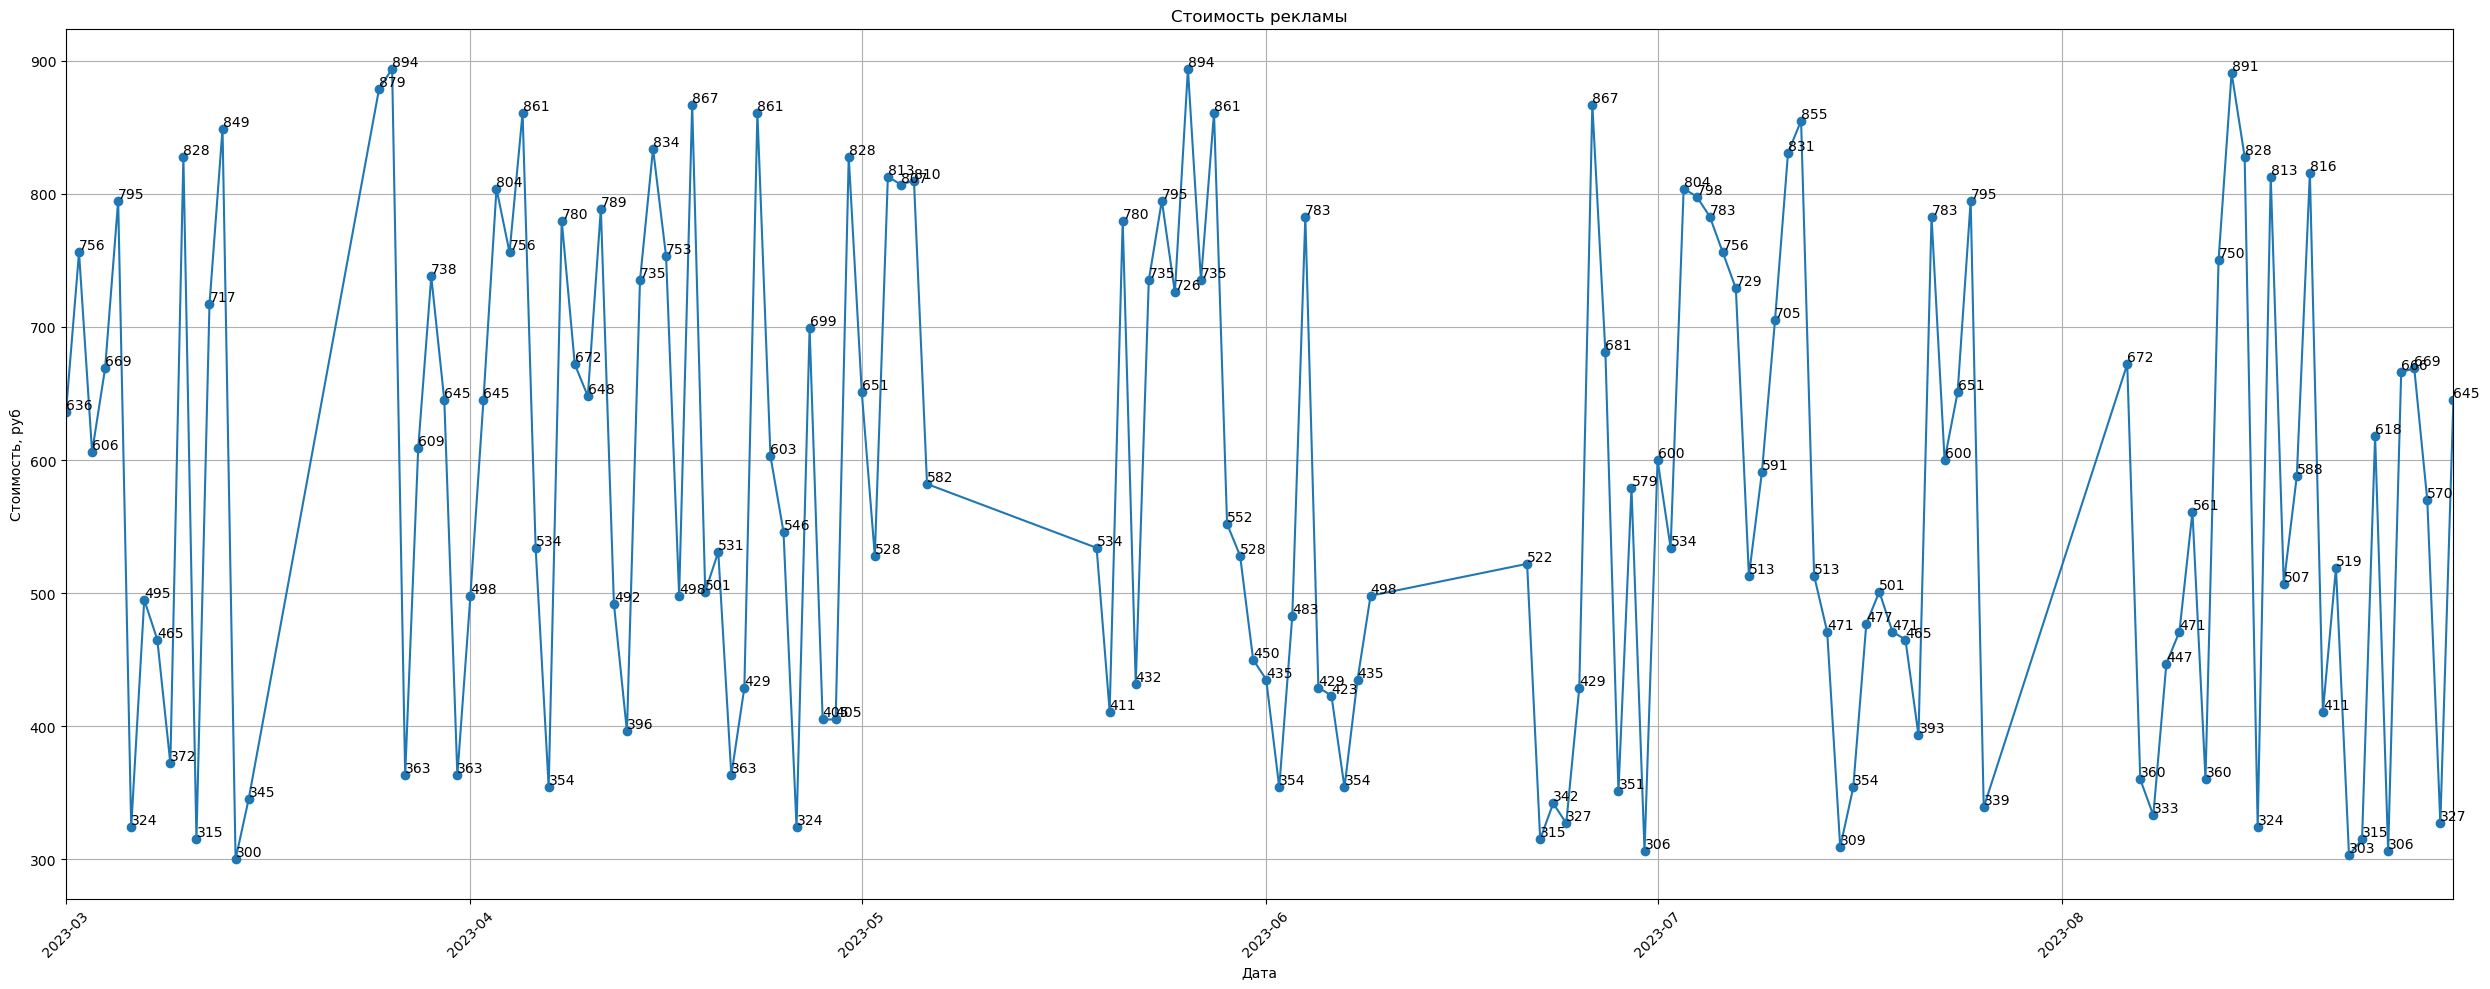

In [133]:
# Построение линейного графика затрат на рекламу
plt.style.use('default')
plt.figure(figsize=(25,10))

plt.plot(plt_ads_cost.index, plt_ads_cost['cost'], marker='o')

plt.title('Стоимость рекламы')
plt.xlabel('Дата')
plt.ylabel('Стоимость, руб')
plt.xticks(rotation=45)
plt.grid(True)

for x, y in zip(plt_ads_cost.index, plt_ads_cost['cost']):
    plt.text(x, y, f'{y:.0f}', ha='left', va='bottom')

plt.margins(x=0)
plt.tight_layout()
plt.savefig('./charts/ads_cost.png')

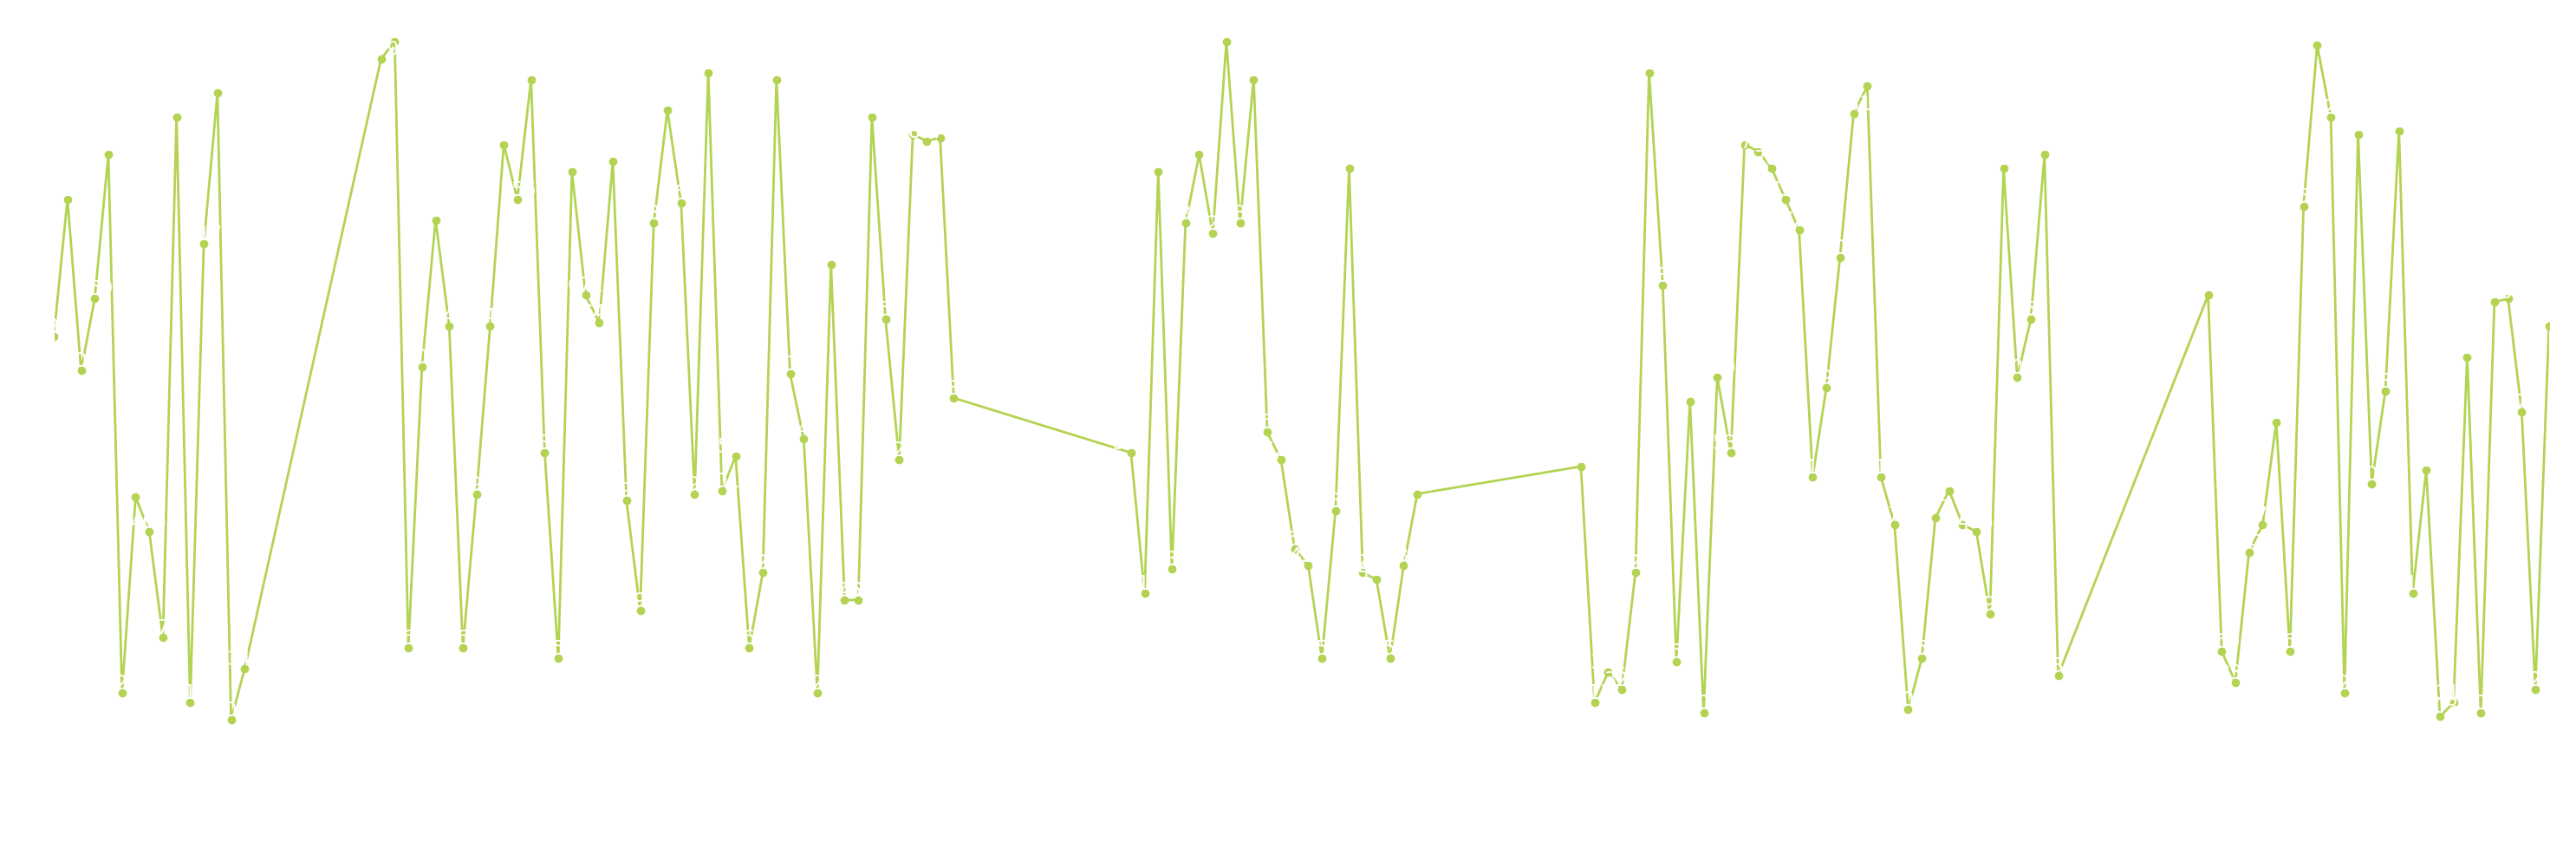

In [186]:
# Построение линейного графика затрат на рекламу
# dark-theme vector
plt.style.use('default')

plt.rcParams.update({
    'font.size': 16
})

fig, ax = plt.subplots(figsize=(30, 10))

ax.plot(
    plt_ads_cost.index,
    plt_ads_cost['cost'],
    marker='o',
    color='#B4D352',
    linewidth=2
)

ax.tick_params(axis='x', colors='white', rotation=45)
ax.tick_params(axis='y', colors='white')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')

ax.grid(axis='y', color='white', linestyle='--', alpha=0.3)

for x, y in zip(plt_ads_cost.index, plt_ads_cost['cost']):
    ax.text(x, y, f'{y:.0f}', ha='center', va='bottom', color='white')

plt.margins(x=0)
plt.tight_layout()

plt.savefig('./presentable_charts/ads_cost_dark.svg', transparent=True)

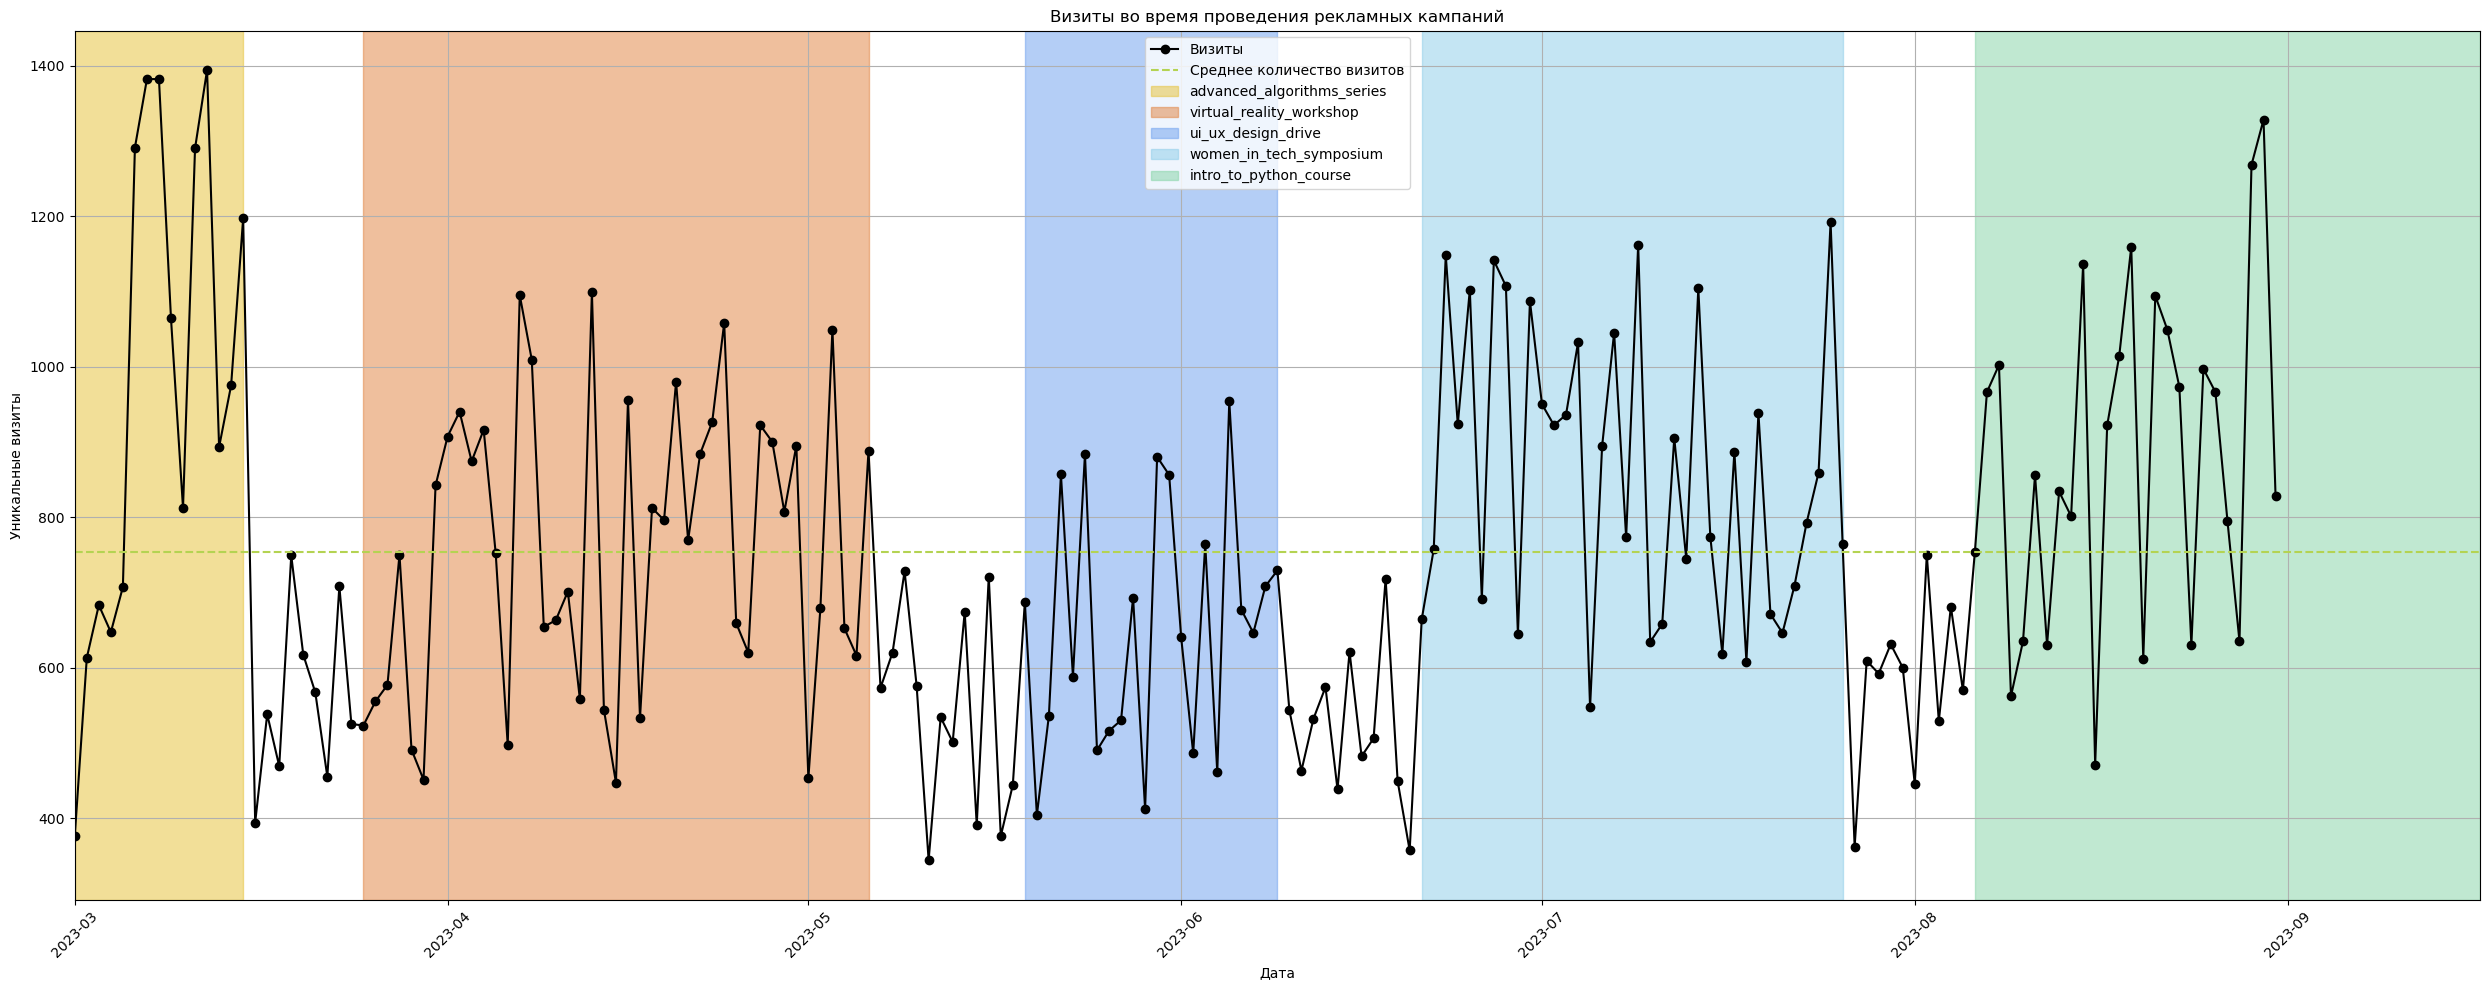

In [179]:
# Построение графика визитов с наложением периодов проведения рекламных кампаний
plot_visits = (
    df_result.groupby('date_group', as_index=False)['visits']
    .sum()
    .sort_values('date_group')
)

plt.figure(figsize=(25, 10))

campaign_dates_sorted = campaign_dates.sort_values('start')
campaign_names = campaign_dates_sorted.index.tolist()

campaign_palette = [
    '#E6C133',  # желтый
    '#E0803C',  # оранжевый
    '#6B9EEE',  # голубой
    '#8ACCE8',  # светло-голубой
    '#83D3A4'   # зеленый
]

campaign_colors = dict(zip(campaign_names, campaign_palette))

plt.plot(
    plot_visits['date_group'],
    plot_visits['visits'],
    marker='o',
    color='black',
    label='Визиты'
)

plt.axhline(
    y=np.nanmean(plot_visits['visits']),
    linestyle='dashed',
    color='#B4D352',
    label='Среднее количество визитов'
)

for campaign, row in campaign_dates_sorted.iterrows():
    plt.axvspan(
        row['start'],
        row['end'],
        color=campaign_colors[campaign],
        alpha=0.5,
        label=campaign
    )

plt.title('Визиты во время проведения рекламных кампаний')
plt.xlabel('Дата')
plt.ylabel('Уникальные визиты')
plt.xticks(rotation=45)
plt.grid(True)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper center')

plt.margins(x=0)
plt.tight_layout()
plt.savefig('./charts/ads_visits.png')

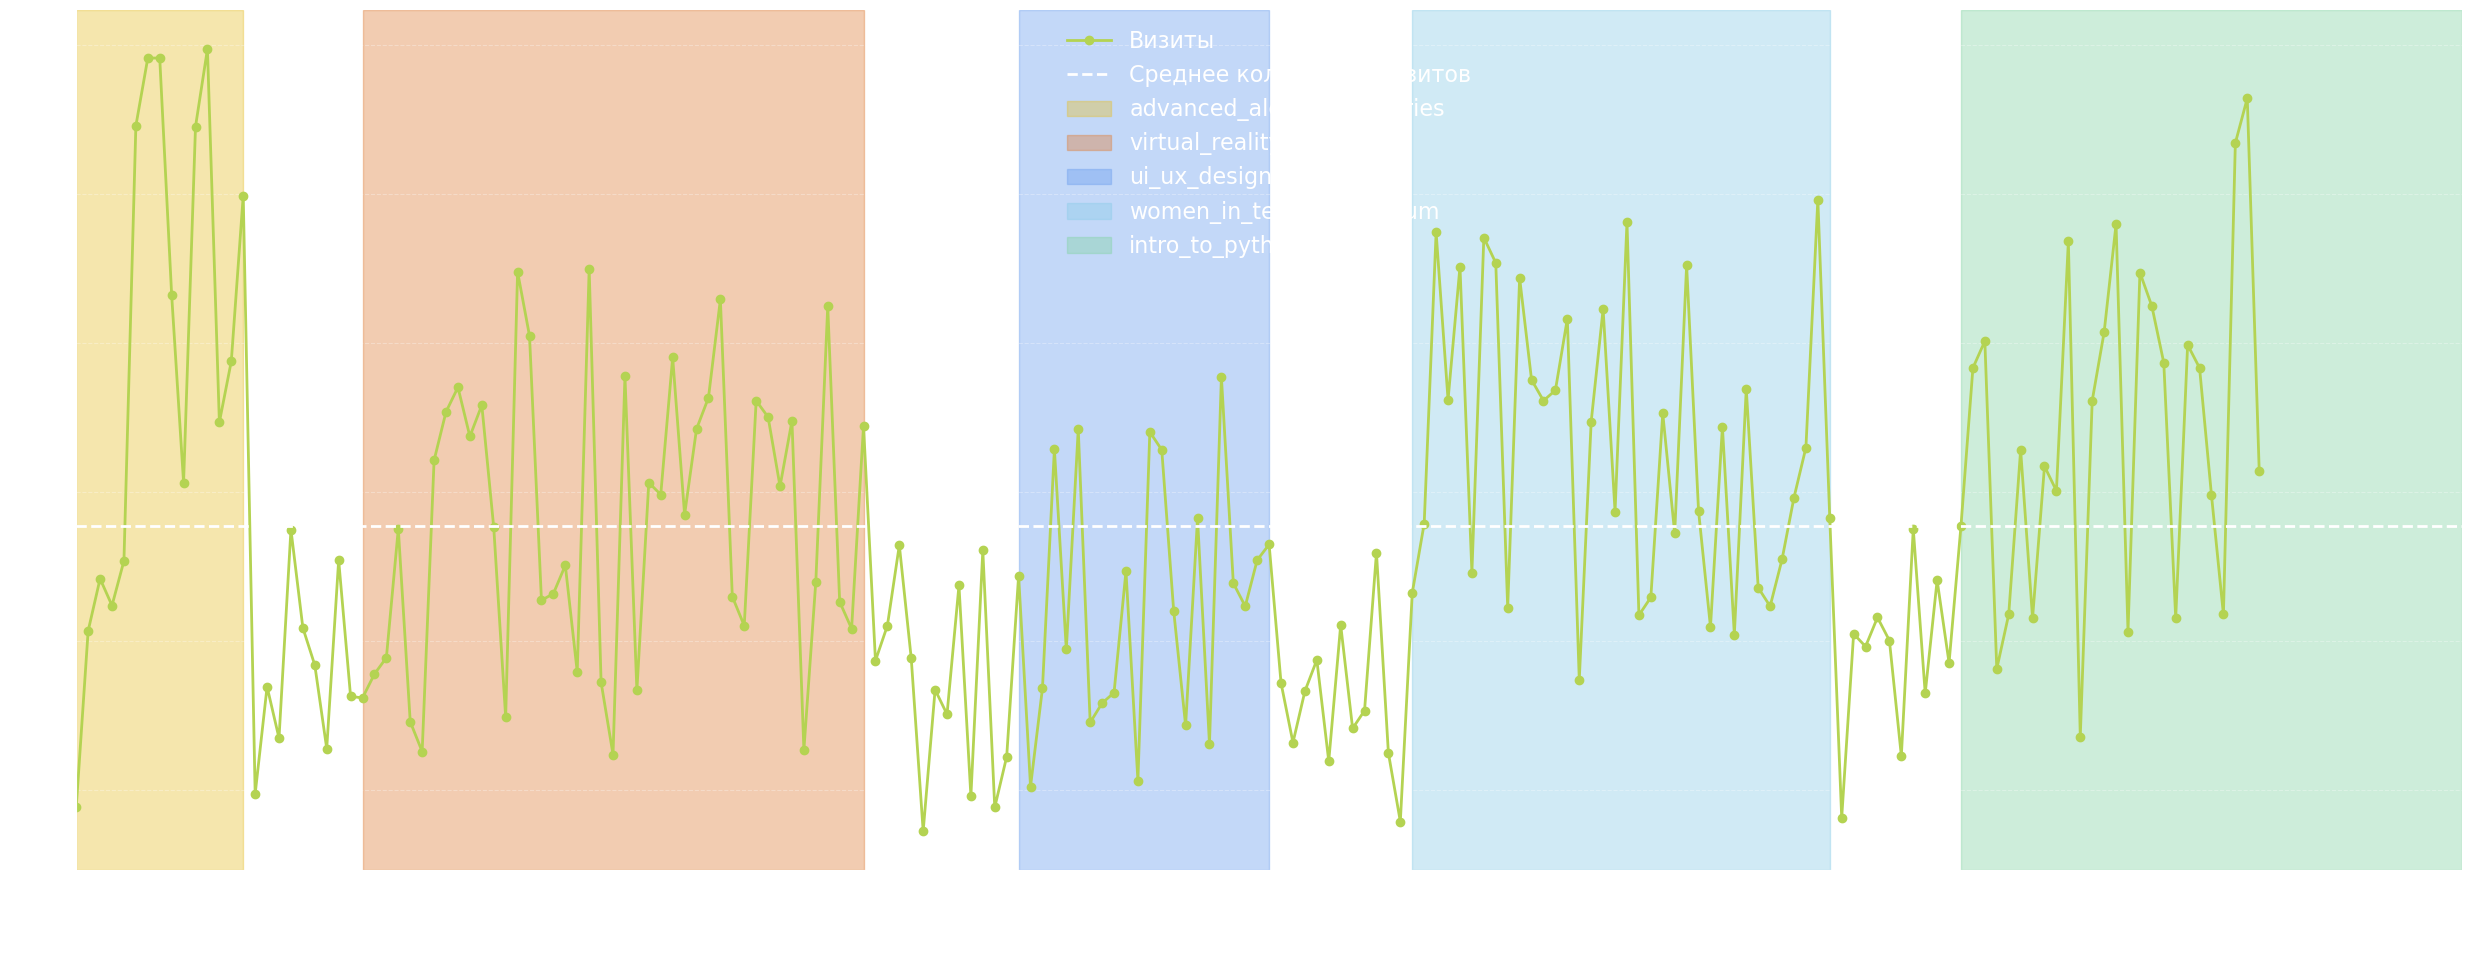

In [187]:
# Построение графика визитов с наложением периодов проведения рекламных кампаний
# dark-theme vector

plt.style.use('default')
plt.rcParams.update({'font.size': 16})

fig, ax = plt.subplots(figsize=(25, 10))

# агрегируем визиты
plot_visits = (
    df_result.groupby('date_group', as_index=False)['visits']
    .sum()
    .sort_values('date_group')
)

# сортируем кампании по start
campaign_dates_sorted = campaign_dates.sort_values('start')
campaign_names = campaign_dates_sorted.index.tolist()

campaign_palette = [
    '#E6C133',
    '#E0803C',
    '#6B9EEE',
    '#8ACCE8',
    '#83D3A4'
]

campaign_colors = dict(zip(campaign_names, campaign_palette))

# линия визитов
ax.plot(
    plot_visits['date_group'],
    plot_visits['visits'],
    marker='o',
    color='#B4D352',
    linewidth=2,
    label='Визиты'
)

# среднее
ax.axhline(
    y=np.nanmean(plot_visits['visits']),
    linestyle='dashed',
    color='white',
    linewidth=2,
    label='Среднее количество визитов'
)

# кампании
for campaign, row in campaign_dates_sorted.iterrows():
    ax.axvspan(
        row['start'],
        row['end'],
        color=campaign_colors[campaign],
        alpha=0.4,
        label=campaign
    )

# стиль осей
ax.tick_params(axis='x', colors='white', rotation=45)
ax.tick_params(axis='y', colors='white')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')

# grid
ax.grid(axis='y', color='white', linestyle='--', alpha=0.3)

# легенда в правильном порядке
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))

order = ['Визиты', 'Среднее количество визитов'] + campaign_names

legend = ax.legend(
    [by_label[o] for o in order],
    order,
    loc='upper center'
)

for text in legend.get_texts():
    text.set_color('white')
legend.get_frame().set_alpha(0)

plt.margins(x=0)
plt.tight_layout()

plt.savefig('./presentable_charts/ads_visits_dark.svg', transparent=True)

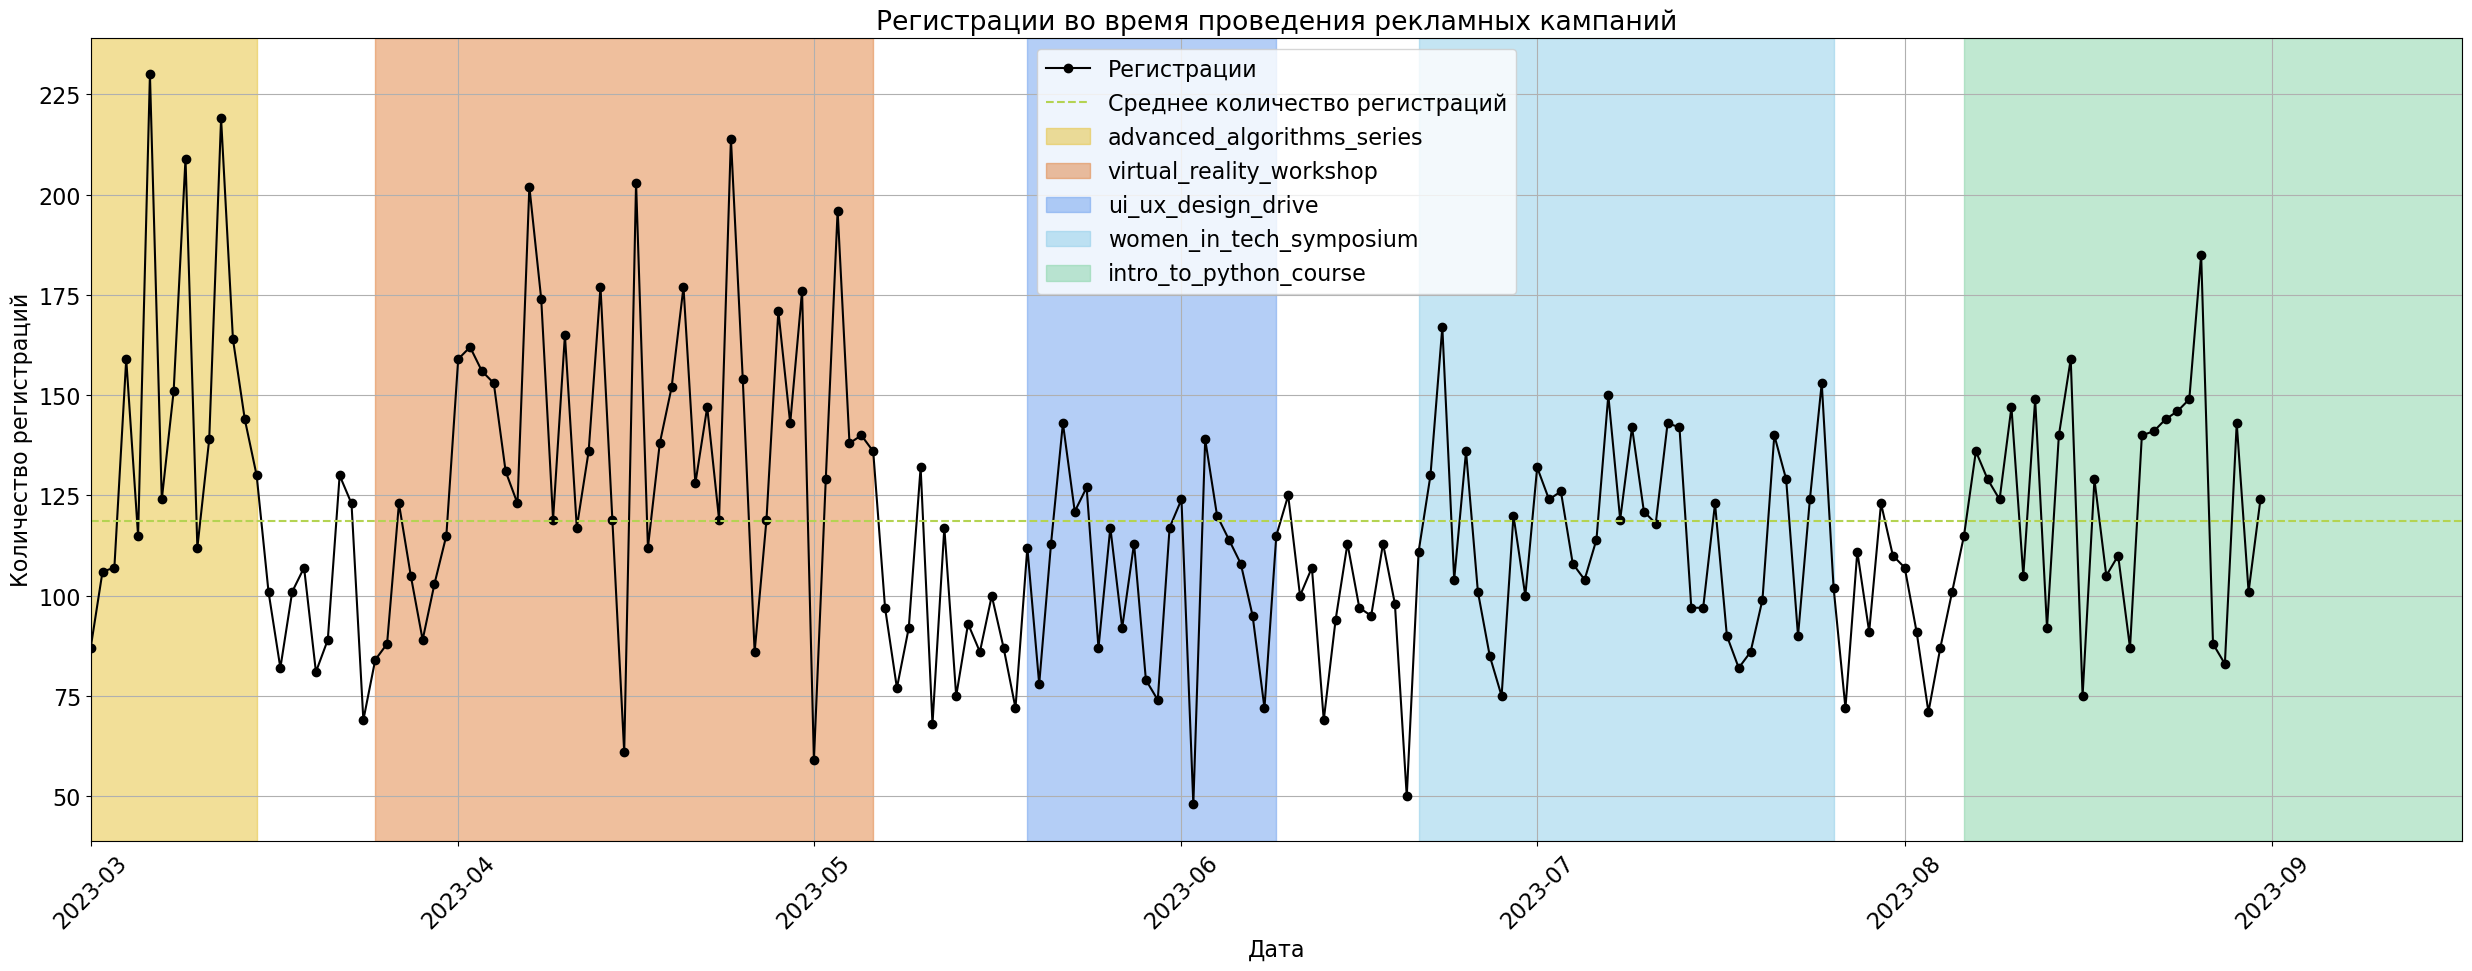

In [188]:
# Построение графика регистраций с наложением периодов проведения рекламных кампаний
plot_visits = (
    df_result.groupby('date_group', as_index=False)['registrations']
    .sum()
    .sort_values('date_group')
)

plt.figure(figsize=(25, 10))

campaign_dates_sorted = campaign_dates.sort_values('start')
campaign_names = campaign_dates_sorted.index.tolist()

campaign_palette = [
    '#E6C133',  # желтый
    '#E0803C',  # оранжевый
    '#6B9EEE',  # голубой
    '#8ACCE8',  # светло-голубой
    '#83D3A4'   # зеленый
]

campaign_colors = dict(zip(campaign_names, campaign_palette))

plt.plot(
    plot_visits['date_group'],
    plot_visits['registrations'],
    marker='o',
    color='black',
    label='Регистрации'
)

plt.axhline(
    y=np.nanmean(plot_visits['registrations']),
    linestyle='dashed',
    color='#B4D352',
    label='Среднее количество регистраций'
)

for campaign, row in campaign_dates_sorted.iterrows():
    plt.axvspan(
        row['start'],
        row['end'],
        color=campaign_colors[campaign],
        alpha=0.5,
        label=campaign
    )

plt.title('Регистрации во время проведения рекламных кампаний')
plt.xlabel('Дата')
plt.ylabel('Количество регистраций')
plt.xticks(rotation=45)
plt.grid(True)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper center')

plt.margins(x=0)
plt.tight_layout()
plt.savefig('./charts/ads_registrations.png')

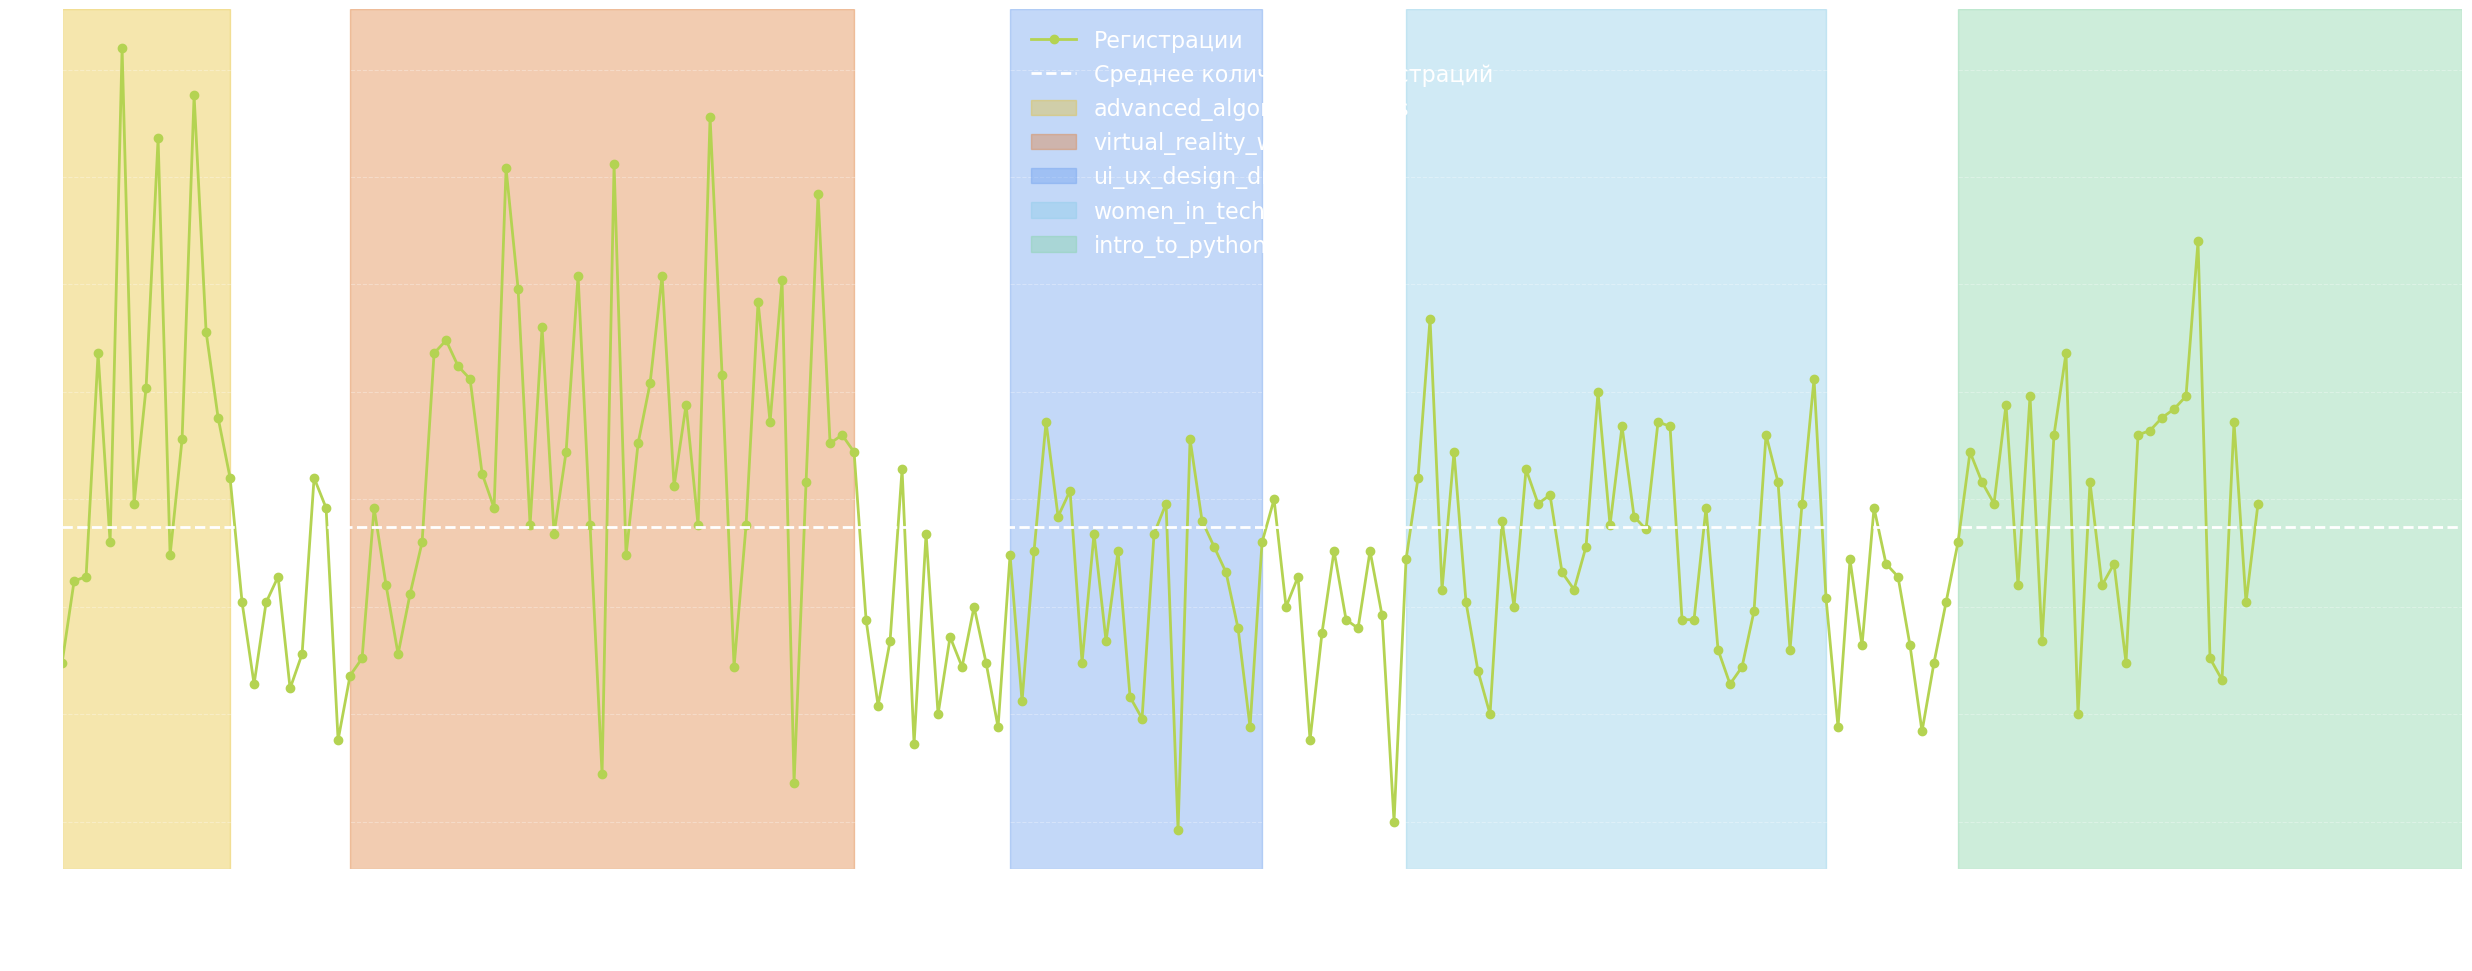

In [189]:
# Построение графика регистраций с наложением периодов проведения рекламных кампаний
# dark-theme vector

plt.style.use('default')
plt.rcParams.update({'font.size': 16})

fig, ax = plt.subplots(figsize=(25, 10))

# агрегируем визиты
plot_visits = (
    df_result.groupby('date_group', as_index=False)['registrations']
    .sum()
    .sort_values('date_group')
)

# сортируем кампании по start
campaign_dates_sorted = campaign_dates.sort_values('start')
campaign_names = campaign_dates_sorted.index.tolist()

campaign_palette = [
    '#E6C133',
    '#E0803C',
    '#6B9EEE',
    '#8ACCE8',
    '#83D3A4'
]

campaign_colors = dict(zip(campaign_names, campaign_palette))

# линия регистраций
ax.plot(
    plot_visits['date_group'],
    plot_visits['registrations'],
    marker='o',
    color='#B4D352',
    linewidth=2,
    label='Регистрации'
)

# среднее
ax.axhline(
    y=np.nanmean(plot_visits['registrations']),
    linestyle='dashed',
    color='white',
    linewidth=2,
    label='Среднее количество регистраций'
)

# кампании
for campaign, row in campaign_dates_sorted.iterrows():
    ax.axvspan(
        row['start'],
        row['end'],
        color=campaign_colors[campaign],
        alpha=0.4,
        label=campaign
    )

# стиль осей
ax.tick_params(axis='x', colors='white', rotation=45)
ax.tick_params(axis='y', colors='white')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')

# grid
ax.grid(axis='y', color='white', linestyle='--', alpha=0.3)

# легенда в правильном порядке
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))

order = ['Регистрации', 'Среднее количество регистраций'] + campaign_names

legend = ax.legend(
    [by_label[o] for o in order],
    order,
    loc='upper center'
)

for text in legend.get_texts():
    text.set_color('white')
legend.get_frame().set_alpha(0)

plt.margins(x=0)
plt.tight_layout()

plt.savefig('./presentable_charts/ads_registrations_dark.svg', transparent=True)